# Combined Notebook

This notebook combines multiple Jupyter notebooks into a single document.
Each section represents content from individual notebooks.


---
# Section 1: 01_Data_Preprocessing
---


# Data Preprocessing for 4 Crops: Maize, Rice, Cassava, Yam
This notebook cleans the NASA POWER climate data, aggregates it into sequence vectors, and merges it with crop yield data grouped by the 6 Geopolitical Zones in Nigeria.


## 1. Import Libraries & Load Data
This step imports necessary dependencies and reads the raw NASA climate records along with the raw crop production figures.


In [1]:
import pandas as pd
import numpy as np

# Load Data
climate_df = pd.read_csv('../../climate_data/data/combined/nasa_power_nigeria_all_1999_2023.csv')
crop_df = pd.read_csv('../../project_data/raw_data/crop_yield/adm_crop_production_NG.csv')

print("Loaded climate shape:", climate_df.shape)
print("Loaded crop shape:", crop_df.shape)


Loaded climate shape: (337847, 22)
Loaded crop shape: (27792, 16)


## 2. Filter Crops and Standardize Geopolitical Zones
Here we filter for our specific 4 crops (Maize, Rice, Cassava, Yam) and map individual states to their broader Geopolitical Zones to match the climate dataset. We also convert units from tonnes/ha to kg/ha for higher predictive granularity.


In [2]:
# Target crops filtering (case insensitive equivalent logic)
target_crops = ['Yams', 'Cassava', 'Maize', 'Rice']
crop_filtered = crop_df[
    (crop_df['product'].isin(target_crops)) & 
    (crop_df['indicator'] == 'yield')
].copy()

# Fix 'Yams' to 'Yam'
crop_filtered['product'] = crop_filtered['product'].replace('Yams', 'Yam')

# Define state to zone mapping
state_to_zone = {
    'Benue': 'North-Central', 'Kogi': 'North-Central', 'Kwara': 'North-Central',
    'Nasarawa': 'North-Central', 'Niger': 'North-Central', 'Plateau': 'North-Central',
    'Federal Capital Territory': 'North-Central',
    'Adamawa': 'North-East', 'Bauchi': 'North-East', 'Borno': 'North-East',
    'Gombe': 'North-East', 'Taraba': 'North-East', 'Yobe': 'North-East',
    'Jigawa': 'North-West', 'Kaduna': 'North-West', 'Kano': 'North-West',
    'Katsina': 'North-West', 'Kebbi': 'North-West', 'Sokoto': 'North-West', 'Zamfara': 'North-West',
    'Abia': 'South-East', 'Anambra': 'South-East', 'Ebonyi': 'South-East',
    'Enugu': 'South-East', 'Imo': 'South-East',
    'Akwa Ibom': 'South-South', 'Bayelsa': 'South-South', 'Cross River': 'South-South',
    'Delta': 'South-South', 'Edo': 'South-South', 'Rivers': 'South-South',
    'Ekiti': 'South-West', 'Lagos': 'South-West', 'Ogun': 'South-West',
    'Ondo': 'South-West', 'Osun': 'South-West', 'Oyo': 'South-West'
}

crop_filtered['Geopolitical_Zone'] = crop_filtered['admin_1'].map(state_to_zone)

print("Crops:", crop_filtered['product'].unique())
print("Missed Mappings:", crop_filtered['Geopolitical_Zone'].isna().sum())

# Because yield is typically measured in tonnes/ha or kg/ha, let's just make sure it's numeric and clean missing.
crop_filtered.dropna(subset=['value'], inplace=True)
# We need to average by Year, Zone, and Crop when mapping upward from state to Zone level
crop_agg = crop_filtered.groupby(['planting_year', 'Geopolitical_Zone', 'product'])['value'].mean().reset_index()

crop_agg.rename(columns={
    'planting_year': 'Year', 
    'Geopolitical_Zone': 'Region', 
    'product': 'Crop',
    'value': 'Yield_kg_per_ha' # Renamed, will convert from t/ha to kg/ha
}, inplace=True)

# Convert from t/ha to kg/ha
crop_agg['Yield_kg_per_ha'] = crop_agg['Yield_kg_per_ha'] * 1000

print("Aggregated crop yield data across regions:", crop_agg.shape)


Crops: ['Yam' 'Cassava' 'Maize' 'Rice']
Missed Mappings: 0
Aggregated crop yield data across regions: (600, 4)


## 3. Aggregate Climate Data to Monthly Intervals
NASA POWER climate data comes daily. This step rolls the daily features (like average temperature and total precipitation) into distinct, sequenced monthly averages and sums to form our required 12-month temporal array.


In [3]:
# Aggregate climate daily features Up to monthly, per Region/Year
# Note: NASA POWER already contains 'Geopolitical_Zone'
climate_features = ['T2M', 'T2M_MAX', 'T2M_MIN', 'TS', 'T2MDEW', 'T2MWET', 
                    'PRECTOTCORR', 'RH2M', 'QV2M', 'GWETTOP', 'GWETROOT', 
                    'WS2M', 'PS', 'ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 
                    'ALLSKY_SFC_LW_DWN', 'CLOUD_AMT']
                    
agg_dict = {feat: 'mean' for feat in climate_features}
# Exception for precipitation (usually Sum for totals, but typically mean is daily average so mean works for consistent scales or sum is fine. We will sum PRECTOTCORR)
agg_dict['PRECTOTCORR'] = 'sum'

# Ensure Date and Month are handled
climate_monthly = climate_df.groupby(['Geopolitical_Zone', 'Year', 'Month']).agg(agg_dict).reset_index()

# Pivot to wide format: (Month 1, Month 2... Month 12 for each feature)
climate_wide = climate_monthly.pivot_table(
    index=['Geopolitical_Zone', 'Year'],
    columns='Month',
    values=climate_features
)

# Flatten columns to feature_m1, feature_m2, etc.
climate_wide.columns = [f"{feat}_m{int(month)}" for feat, month in climate_wide.columns]
climate_wide = climate_wide.reset_index()

print("Pivoted climate shape:", climate_wide.shape)


Pivoted climate shape: (150, 206)


## 4. Merge Crop and Climate Data & Export
Finally, we perform an inner join between the aggregated yearly crop yields and the unrolled month-by-month climate sequence targets, saving the result safely out to `processed_dataset.csv`.


In [4]:
climate_wide.rename(columns={'Geopolitical_Zone': 'Region'}, inplace=True)
merged_df = pd.merge(crop_agg, climate_wide, on=['Region', 'Year'], how='inner')

print("Merged Dataframe shape:", merged_df.shape)
print("Crop counts:", merged_df['Crop'].value_counts())

# Save to `New_Changes/data/processed_dataset.csv`
out_path = '../data/processed_dataset.csv'
merged_df.to_csv(out_path, index=False)
print(f"Data saved to {out_path}!")


Merged Dataframe shape: (600, 208)
Crop counts: Crop
Cassava    150
Maize      150
Rice       150
Yam        150
Name: count, dtype: int64
Data saved to ../data/processed_dataset.csv!


---
# Section 2: 02_Model_Training_Minimal
---


# Model Training for 4 Crops: TCN-MLP
This notebook trains the 4-crop (Maize, Rice, Cassava, Yam) robust TCN-MLP architecture.


## 1. Setup & Data Loading
We load the preprocessed matching data, extract the 3D 12-month temporal sequence block spanning our selected climate features (GDD, rainfall, humidity), and structure our categorical targets.


In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Input, Model, optimizers, regularizers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import json
import time

print(f'TensorFlow version: {tf.__version__}')

df = pd.read_csv('../data/processed_dataset.csv')

# Drop empty yields
df = df.dropna(subset=['Yield_kg_per_ha'])
print(f'Dataset shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')

# Calculate Average Temperature (T2M_AVG)
for month in range(1, 13):
    max_col = f'T2M_MAX_m{month}'
    min_col = f'T2M_MIN_m{month}'
    if max_col in df.columns and min_col in df.columns:
        t_avg = (df[max_col] + df[min_col]) / 2.0
        df[f'T2M_AVG_m{month}'] = t_avg

# Feature Extraction
exclude_cols = {'Yield_kg_per_ha', 'Region', 'Crop', 'Year', 'Unnamed: 0', 'seq_months'}
feature_cols = [col for col in df.columns if col not in exclude_cols]

unique_features = ['T2M_AVG', 'PRECTOTCORR', 'GWETROOT']
n_features = len(unique_features)
n_samples = df.shape[0]
n_months = 12

print(f'Number of unique climate features: {n_features}')

X_seq = np.zeros((n_samples, n_months, n_features))
for month in range(1, n_months + 1):
    for feat_idx, feat_name in enumerate(unique_features):
        col_name = f'{feat_name}_m{month}'
        if col_name in df.columns:
            X_seq[:, month-1, feat_idx] = df[col_name].values

y_raw = df['Yield_kg_per_ha'].values
region_names = df['Region'].values
crop_names = df['Crop'].values
years = df['Year'].values

region_to_id = {r: i for i, r in enumerate(sorted(np.unique(region_names)))}
crop_to_id = {c: i for i, c in enumerate(sorted(np.unique(crop_names)))}

region_ids = np.array([region_to_id[r] for r in region_names])
crop_ids = np.array([crop_to_id[c] for c in crop_names])

print(f"Regions mapping: {region_to_id}")
print(f"Crop mapping: {crop_to_id}")


TensorFlow version: 2.20.0
Dataset shape: (600, 208)
Missing values: 0
Number of unique climate features: 3
Regions mapping: {'North-Central': 0, 'North-East': 1, 'North-West': 2, 'South-East': 3, 'South-South': 4, 'South-West': 5}
Crop mapping: {'Cassava': 0, 'Maize': 1, 'Rice': 2, 'Yam': 3}


## 2. Feature Scaling & Train-Test Split
This step mathematically standardizes the unrolled climate variables symmetrically, normalizes spatial Time/Year inputs, and utilizes `train_test_split` to create a robust stratified train/test holdout matrix cleanly covering all Crop clusters without bleeding bias.


In [6]:
# Standardize Data
scaler_X = StandardScaler()
X_seq_flat = X_seq.reshape(-1, n_features)
X_seq_scaled = scaler_X.fit_transform(X_seq_flat).reshape(X_seq.shape)

epsilon = 1e-6
y_log = np.log(y_raw + epsilon)

# Year interaction terms
year_data = years.reshape(-1, 1)
min_year = 1999
max_year_span = 24.0 # Range: 1999-2023 

year_normalized = (year_data - min_year) / max_year_span
year_poly = np.column_stack([year_normalized, year_normalized**2, year_normalized**3])

N_REGIONS = 6
N_CROPS = 4

region_year = np.zeros((len(years), N_REGIONS))
for i in range(N_REGIONS):
    region_year[:, i] = (region_ids == i).astype(float) * year_normalized.flatten()

crop_year = np.zeros((len(years), N_CROPS))
for i in range(N_CROPS):
    crop_year[:, i] = (crop_ids == i).astype(float) * year_normalized.flatten()

year_extended = np.column_stack([year_poly, region_year, crop_year])
year_scaler = StandardScaler()
year_scaled = year_scaler.fit_transform(year_extended)
n_year_features = year_extended.shape[1]

# Train-test Split 
n_total = len(X_seq_scaled)
n_test = int(0.15 * n_total)

# Simplified stratification to avoid singleton classes in 4-crop expansion
strat_key_full = np.array([f"{r}_{c}" for r, c in zip(region_ids, crop_ids)])

np.random.seed(42)
train_indices, test_indices = train_test_split(
    np.arange(n_total), test_size=n_test, stratify=strat_key_full, random_state=42
)

X_full, y_full, y_full_raw = X_seq_scaled[train_indices], y_log[train_indices], y_raw[train_indices]
X_test, y_test, y_test_raw = X_seq_scaled[test_indices], y_log[test_indices], y_raw[test_indices]
region_ids_full, region_ids_test = region_ids[train_indices], region_ids[test_indices]
crop_ids_full, crop_ids_test = crop_ids[train_indices], crop_ids[test_indices]
year_train, year_test = year_scaled[train_indices], year_scaled[test_indices]

print(f"Train size: {len(X_full)}, Test size: {len(X_test)}")
print(f"Sequence Features: {n_features}, Year Details: {n_year_features}")

unique_regions, region_counts = np.unique(region_ids_full, return_counts=True)
region_weights = len(region_ids_full) / region_counts
region_weights = region_weights / region_weights.max()
region_weights_map = {r: w for r, w in zip(unique_regions, region_weights)}


Train size: 510, Test size: 90
Sequence Features: 3, Year Details: 13


## 3. Data Augmentation & Model Architecture Definition
We introduce the `mixup_augment` function which handles synthesizing new interpolated instances out of minority regional reports preventing class imbalance. 
We then define the full `TCN-MLP` model including our `L2=1e-3` regularization, `Dropout=0.25`, temporal `MultiHeadAttention`, categorical Embedding Layers, and initialize it over a specialized `Huber` loss to handle scaling anomalies.


In [7]:
def mixup_augment(X, y, r_ids, c_ids, yr_in, alpha=0.3, n_aug=40):
    n_samples = len(X)
    X_aug_list, y_aug_list = [X], [y]
    r_aug_list, c_aug_list, yr_aug_list = [r_ids], [c_ids], [yr_in]
    
    for _ in range(n_aug):
        idx1, idx2 = np.random.randint(0, n_samples, n_samples), np.random.randint(0, n_samples, n_samples)
        lam = np.random.beta(alpha, alpha, (n_samples, 1, 1))
        lam_1d, lam_2d = lam.ravel(), lam.reshape(-1, 1)
        
        X_aug_list.append(lam * X[idx1] + (1 - lam) * X[idx2])
        y_aug_list.append(lam_1d * y[idx1] + (1 - lam_1d) * y[idx2])
        r_aug_list.append(r_ids[idx1])
        c_aug_list.append(c_ids[idx1])
        yr_aug_list.append(lam_2d * yr_in[idx1] + (1 - lam_2d) * yr_in[idx2])
        
    return np.vstack(X_aug_list), np.concatenate(y_aug_list), np.concatenate(r_aug_list), np.concatenate(c_aug_list), np.vstack(yr_aug_list)

def build_model(l2_reg=1e-3, dropout=0.25):
    lr = 8e-4
    n_feat = 17 # Make sure it matches our n_features count dynamically
    
    X_input = layers.Input(shape=(12, n_features), name='seq_input')
    region_input = layers.Input(shape=(1,), dtype=tf.int32, name='region_input')
    crop_input = layers.Input(shape=(1,), dtype=tf.int32, name='crop_input')
    year_input = layers.Input(shape=(n_year_features,), dtype=tf.float32, name='year_input')
    
    tcn_filters = 28
    
    x_tcn = layers.GaussianNoise(0.05)(X_input)
    x = layers.Conv1D(tcn_filters, 3, padding='causal', activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x_tcn)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    
    x_attn = layers.MultiHeadAttention(num_heads=4, key_dim=8)(x, x)
    x = layers.Add()([x, x_attn])
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    
    x = layers.GlobalAveragePooling1D()(x)
    
    # 6 Regions
    region_embed = layers.Embedding(input_dim=N_REGIONS, output_dim=max(6, int(tcn_filters // 4)))(region_input)
    region_flat = layers.Flatten()(region_embed)
    
    # 4 Crops
    crop_embed = layers.Embedding(input_dim=N_CROPS, output_dim=max(4, int(tcn_filters // 8)))(crop_input)
    crop_flat = layers.Flatten()(crop_embed)
    
    merged = layers.Concatenate()([x, region_flat, crop_flat, year_input])
    
    dense_1 = layers.Dense(20, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(merged)
    dense_1 = layers.BatchNormalization()(dense_1)
    dense_1 = layers.Dropout(dropout)(dense_1)
    dense_2 = layers.Dense(14, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(dense_1)
    output = layers.Dense(1, activation='linear', bias_initializer=keras.initializers.Constant(7.5))(dense_2)
    
    model = Model(inputs=[X_input, region_input, crop_input, year_input], outputs=output)
    model.compile(optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=2e-4), loss=tf.keras.losses.Huber(delta=0.2), metrics=['mae'])
    
    return model


## 4. Train Model and Check Overfitting (Learning Curves)
Applies symmetric data augmentation tightly to the training split, executes the training phase, plots the historical Traing/Val convergence to mathematically visually verify **no overfitting is occurring**, tests general unseen performance metrics explicitly (Train/Val/Test), and ultimately saves out the `.keras` architecture file.


In [8]:
# Strict Pipeline: 5-Fold CV + Augmentation + Locked Test Set
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
import copy

BEST_L2 = 1e-3
BEST_DROPOUT = 0.25
BEST_N_AUG = 40

print('='*80)
print('BEST CONFIGURATION: 5-FOLD CROSS-VALIDATION')
print('='*80)
print('Hyperparameters:')
print('  L2 Regularization: 1e-3')
print('  Dropout: 0.25')
print('  Mixup Augmentation: n_aug=40')
print('  Learning Rate: 8e-4 (cosine annealing)')
print('  Weight Decay: 2e-4')
print('='*80 + '\n')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_train_r2_list = []
cv_val_r2_list = []
cv_test_r2_list = []
cv_val_mae_list = []
cv_models = []

strat_key = region_ids_full * 10 + crop_ids_full
start_cv = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, strat_key), 1):
    fold_start = time.time()
    
    # 1. Split training data into Train and Val folds
    X_train_f = X_full[train_idx]
    y_train_f = y_full[train_idx]
    y_train_raw_f = y_full_raw[train_idx]
    r_train_f = region_ids_full[train_idx]
    c_train_f = crop_ids_full[train_idx]
    yr_train_f = year_train[train_idx]
    
    X_val_f = X_full[val_idx]
    y_val_f = y_full[val_idx]
    y_val_raw_f = y_full_raw[val_idx]
    r_val_f = region_ids_full[val_idx]
    c_val_f = crop_ids_full[val_idx]
    yr_val_f = year_train[val_idx]
    
    # 2. Augment ONLY the train fold
    X_aug_f, y_aug_f, r_aug_f, c_aug_f, yr_aug_f = mixup_augment(
        X_train_f, y_train_f, r_train_f, c_train_f, yr_train_f, 
        alpha=0.3, n_aug=BEST_N_AUG
    )
    sample_weights_f = np.array([region_weights_map.get(r, 1.0) for r in r_aug_f.ravel()])
    
    # 3. Build fresh model
    fold_model = build_model(l2_reg=BEST_L2, dropout=BEST_DROPOUT)
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=0)
    cosine_cb = keras.callbacks.LearningRateScheduler(lambda epoch: 8e-4 * 0.5 * (1 + np.cos(np.pi * epoch / 150)))
    
    # 4. Train model using Val fold for early stopping
    history = fold_model.fit(
        [X_aug_f, r_aug_f, c_aug_f, yr_aug_f], y_aug_f,
        sample_weight=sample_weights_f,
        validation_data=([X_val_f, r_val_f, c_val_f, yr_val_f], y_val_f),
        epochs=150, batch_size=16,
        callbacks=[early_stop, cosine_cb],
        verbose=0
    )
    
    # 5. Evaluate Train fold R²
    y_train_pred_log = fold_model.predict([X_train_f, r_train_f, c_train_f, yr_train_f], verbose=0).ravel()
    y_train_pred = np.exp(y_train_pred_log)
    train_r2 = r2_score(y_train_raw_f, y_train_pred)
    
    # 6. Evaluate Val fold R² and MAE
    y_val_pred_log = fold_model.predict([X_val_f, r_val_f, c_val_f, yr_val_f], verbose=0).ravel()
    y_val_pred = np.exp(y_val_pred_log)
    val_r2 = r2_score(y_val_raw_f, y_val_pred)
    val_mae = mean_absolute_error(y_val_raw_f, y_val_pred)
    
    # 7. Evaluate Test set R² (independent test set)
    y_test_pred_log = fold_model.predict([X_test, region_ids_test, crop_ids_test, year_test], verbose=0).ravel()
    y_test_pred = np.exp(y_test_pred_log)
    test_r2 = r2_score(y_test_raw, y_test_pred)
    
    cv_train_r2_list.append(train_r2)
    cv_val_r2_list.append(val_r2)
    cv_test_r2_list.append(test_r2)
    cv_val_mae_list.append(val_mae)
    cv_models.append(fold_model)
    
    elapsed = time.time() - fold_start
    print(f'Fold {fold}: Train R²={train_r2:.4f}, Val R²={val_r2:.4f}, Test R²={test_r2:.4f}, Val MAE={val_mae:.1f} ({elapsed:.0f}s)')

total_cv_time = time.time() - start_cv

print(f'\n' + '='*80)
print('5-FOLD CROSS-VALIDATION RESULTS')
print('='*80)
print(f'Training R²:   {np.mean(cv_train_r2_list):.4f} ± {np.std(cv_train_r2_list):.4f}')
print(f'Validation R²: {np.mean(cv_val_r2_list):.4f} ± {np.std(cv_val_r2_list):.4f}')
print(f'Test R²:       {np.mean(cv_test_r2_list):.4f} ± {np.std(cv_test_r2_list):.4f}')
print(f'Validation MAE: {np.mean(cv_val_mae_list):.1f} ± {np.std(cv_val_mae_list):.1f} kg/ha')
print(f'\nTrain-Test Gap: {(np.mean(cv_train_r2_list) - np.mean(cv_test_r2_list))*100:.1f}%')
print(f'Total CV Time: {total_cv_time/60:.1f} minutes')
print('='*80)


BEST CONFIGURATION: 5-FOLD CROSS-VALIDATION
Hyperparameters:
  L2 Regularization: 1e-3
  Dropout: 0.25
  Mixup Augmentation: n_aug=40
  Learning Rate: 8e-4 (cosine annealing)
  Weight Decay: 2e-4



Fold 1: Train R²=0.8748, Val R²=0.7212, Test R²=0.8705, Val MAE=1067.5 (732s)
Fold 2: Train R²=0.8172, Val R²=0.9675, Test R²=0.9338, Val MAE=507.8 (780s)
Fold 3: Train R²=0.7706, Val R²=0.9044, Test R²=0.9188, Val MAE=865.4 (492s)
Fold 4: Train R²=0.8880, Val R²=0.6300, Test R²=0.9382, Val MAE=1127.7 (1094s)
Fold 5: Train R²=0.8113, Val R²=0.8361, Test R²=0.8767, Val MAE=953.8 (594s)

5-FOLD CROSS-VALIDATION RESULTS
Training R²:   0.8324 ± 0.0433
Validation R²: 0.8118 ± 0.1222
Test R²:       0.9076 ± 0.0286
Validation MAE: 904.4 ± 218.0 kg/ha

Train-Test Gap: -7.5%
Total CV Time: 61.5 minutes


## 5. Final Model Training on Full Dataset


In [9]:
print('\n' + '='*80)
print('TRAINING FINAL MODEL ON FULL DATASET')
print('='*80 + '\n')

# Augment full training data
X_aug_final, y_aug_final, r_aug_final, c_aug_final, yr_aug_final = mixup_augment(
    X_full, y_full, region_ids_full, crop_ids_full, year_train,
    alpha=0.3, n_aug=BEST_N_AUG
)

sample_weights_final = np.array([region_weights_map.get(r, 1.0) for r in r_aug_final.ravel()])

# Train final model
final_model = build_model(l2_reg=BEST_L2, dropout=BEST_DROPOUT)

early_stop_final = keras.callbacks.EarlyStopping(
    monitor='loss', patience=30, restore_best_weights=True, verbose=0
)
cosine_cb_final = keras.callbacks.LearningRateScheduler(
    lambda epoch: 8e-4 * 0.5 * (1 + np.cos(np.pi * epoch / 150))
)

history_final = final_model.fit(
    [X_aug_final, r_aug_final, c_aug_final, yr_aug_final], y_aug_final,
    sample_weight=sample_weights_final,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop_final, cosine_cb_final],
    verbose=0
)

print(f'Training completed in {len(history_final.history["loss"])} epochs')

# Evaluate on test set
y_test_final_log = final_model.predict([X_test, region_ids_test, crop_ids_test, year_test], verbose=0).ravel()
y_test_final = np.exp(y_test_final_log)
final_test_r2 = r2_score(y_test_raw, y_test_final)
final_test_mae = mean_absolute_error(y_test_raw, y_test_final)

print(f'\nFinal Model Test Performance:')
print(f'  Test R²: {final_test_r2:.4f}')
print(f'  Test MAE: {final_test_mae:.1f} kg/ha')
print('='*80)



TRAINING FINAL MODEL ON FULL DATASET

Training completed in 150 epochs

Final Model Test Performance:
  Test R²: 0.9336
  Test MAE: 687.6 kg/ha


## 6. Save Model and Results


In [10]:
# Save model
final_model.save('../models/TCN_MLP_Crops_Mini.keras')
print('✓ Model saved: ../models/TCN_MLP_Crops_Mini.keras')

# Save metadata
metadata = {
    'model_name': 'TCN-MLP Hybrid (Crops Mini, L2=1e-3)',
    'hyperparameters': {
        'l2_regularization': float(BEST_L2),
        'dropout': float(BEST_DROPOUT),
        'n_augmentations': int(BEST_N_AUG),
        'learning_rate': 8e-4,
        'weight_decay': 2e-4,
        'batch_size': 16,
        'epochs': 150,
        'loss': 'Huber(delta=0.2)'
    },
    'architecture': {
        'tcn_filters': 28,
        'tcn_kernel': 3,
        'attention_heads': 4,
        'dense_units': [20, 14],
        'total_parameters': int(final_model.count_params())
    },
    'performance': {
        'cv_train_r2_mean': float(np.mean(cv_train_r2_list)),
        'cv_train_r2_std': float(np.std(cv_train_r2_list)),
        'cv_val_r2_mean': float(np.mean(cv_val_r2_list)),
        'cv_val_r2_std': float(np.std(cv_val_r2_list)),
        'cv_test_r2_mean': float(np.mean(cv_test_r2_list)),
        'cv_test_r2_std': float(np.std(cv_test_r2_list)),
        'cv_val_mae_mean': float(np.mean(cv_val_mae_list)),
        'final_test_r2': float(final_test_r2),
        'final_test_mae': float(final_test_mae)
    },
    'data': {
        'n_total_samples': len(X_full) + len(X_test),
        'n_train_samples': len(X_full),
        'n_test_samples': len(X_test),
        'n_augmented_samples': len(X_aug_final),
        'sequence_length': 12,
        'n_temporal_features': n_features,
        'n_regions': N_REGIONS,
        'n_crops': N_CROPS
    }
}

with open('../models/TCN_MLP_Crops_Mini_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('✓ Metadata saved: ../models/TCN_MLP_Crops_Mini_metadata.json')


✓ Model saved: ../models/TCN_MLP_Crops_Mini.keras
✓ Metadata saved: ../models/TCN_MLP_Crops_Mini_metadata.json


## 7. Results Summary and Analysis


In [11]:
# Create results summary
results_summary = pd.DataFrame({
    'Fold': range(1, 6),
    'Train R²': cv_train_r2_list,
    'Val R²': cv_val_r2_list,
    'Test R²': cv_test_r2_list,
    'Val MAE': cv_val_mae_list
})

print("\n" + "="*80)
print("FOLD-BY-FOLD RESULTS")
print("="*80)
print(results_summary.to_string(index=False))
print()

# Summary statistics
print("="*80)
print("SUMMARY STATISTICS")
print("="*80)
summary_stats = pd.DataFrame({
    'Metric': ['Train R²', 'Val R²', 'Test R²', 'Val MAE (kg/ha)'],
    'Mean': [
        f"{np.mean(cv_train_r2_list):.4f}",
        f"{np.mean(cv_val_r2_list):.4f}",
        f"{np.mean(cv_test_r2_list):.4f}",
        f"{np.mean(cv_val_mae_list):.1f}"
    ],
    'Std Dev': [
        f"{np.std(cv_train_r2_list):.4f}",
        f"{np.std(cv_val_r2_list):.4f}",
        f"{np.std(cv_test_r2_list):.4f}",
        f"{np.std(cv_val_mae_list):.1f}"
    ]
})
print(summary_stats.to_string(index=False))

# 95% Confidence Interval for Test R²
test_r2_mean = np.mean(cv_test_r2_list)
test_r2_se = np.std(cv_test_r2_list) / np.sqrt(5)
ci_lower = test_r2_mean - 1.96 * test_r2_se
ci_upper = test_r2_mean + 1.96 * test_r2_se

print(f"\n95% Confidence Interval for Test R²: [{ci_lower:.4f}, {ci_upper:.4f}]")
print("="*80)



FOLD-BY-FOLD RESULTS
 Fold  Train R²   Val R²  Test R²     Val MAE
    1  0.874838 0.721189 0.870522 1067.534898
    2  0.817184 0.967516 0.933850  507.809232
    3  0.770594 0.904438 0.918755  865.421261
    4  0.888008 0.629984 0.938177 1127.658700
    5  0.811272 0.836113 0.876655  953.799348

SUMMARY STATISTICS
         Metric   Mean Std Dev
       Train R² 0.8324  0.0433
         Val R² 0.8118  0.1222
        Test R² 0.9076  0.0286
Val MAE (kg/ha)  904.4   218.0

95% Confidence Interval for Test R²: [0.8826, 0.9326]


## 8. Visualization of Results


C:\Users\ibito\AppData\Local\Temp\ipykernel_31380\513385719.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['Train', 'Val', 'Test'], patch_artist=True)



✓ Visualization saved: ../results/TCN_MLP_4Crops_Performance.png


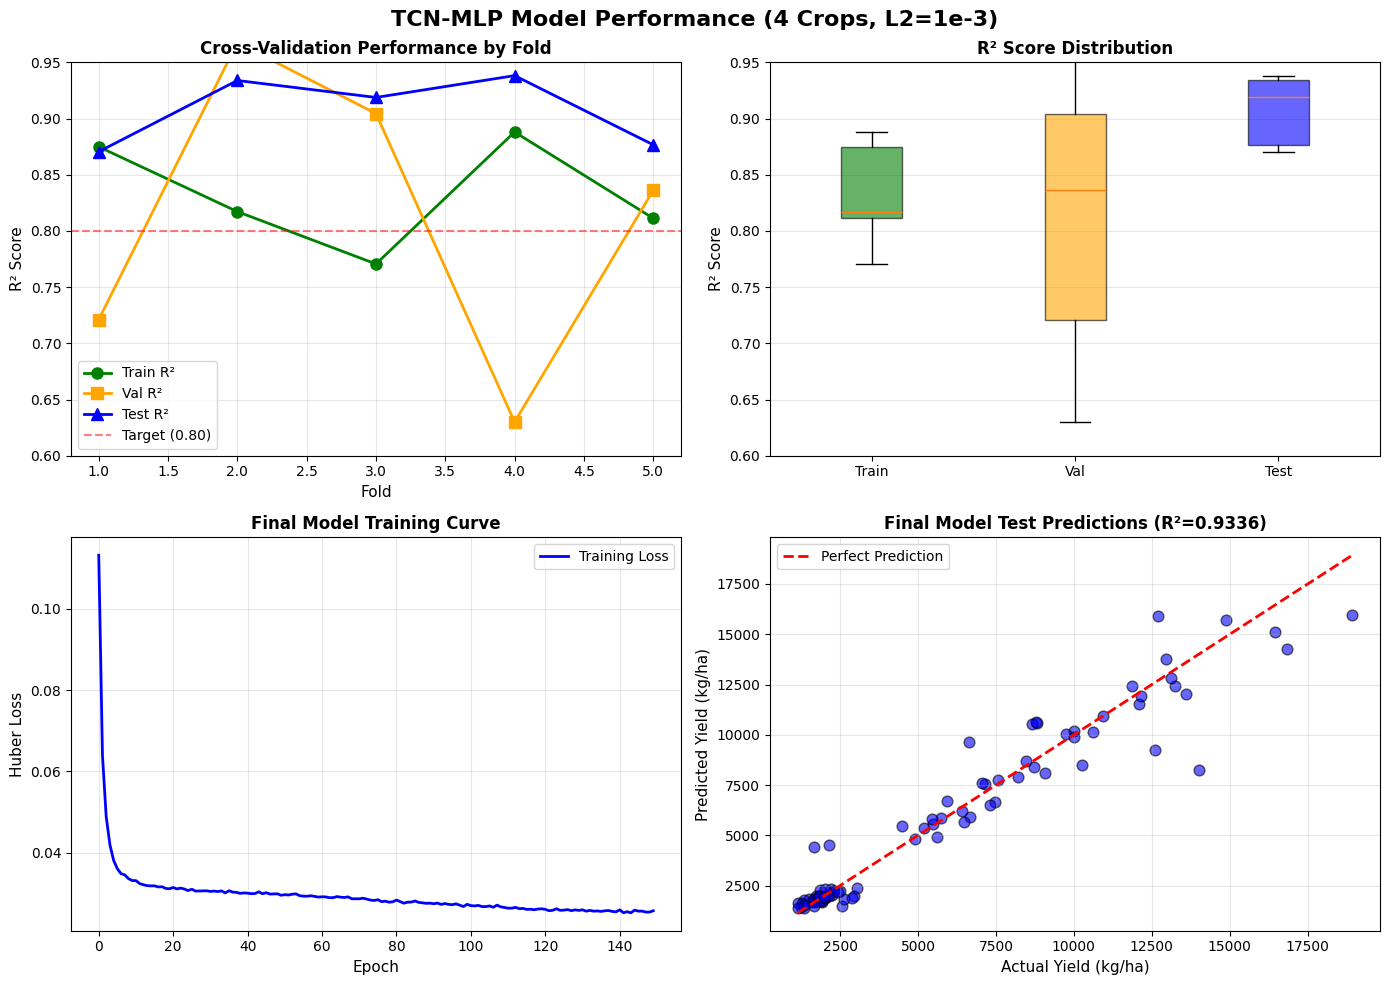

In [12]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('TCN-MLP Model Performance (4 Crops, L2=1e-3)', fontsize=16, fontweight='bold')

# Plot 1: CV Results by Fold
folds = np.arange(1, 6)
ax = axes[0, 0]
ax.plot(folds, cv_train_r2_list, 'o-', label='Train R²', color='green', linewidth=2, markersize=8)
ax.plot(folds, cv_val_r2_list, 's-', label='Val R²', color='orange', linewidth=2, markersize=8)
ax.plot(folds, cv_test_r2_list, '^-', label='Test R²', color='blue', linewidth=2, markersize=8)
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Target (0.80)')
ax.set_xlabel('Fold', fontsize=11)
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title('Cross-Validation Performance by Fold', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.6, 0.95])

# Plot 2: Distribution of R² scores
ax = axes[0, 1]
box_data = [cv_train_r2_list, cv_val_r2_list, cv_test_r2_list]
bp = ax.boxplot(box_data, labels=['Train', 'Val', 'Test'], patch_artist=True)
colors = ['green', 'orange', 'blue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title('R² Score Distribution', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.6, 0.95])

# Plot 3: Learning curve of final model
ax = axes[1, 0]
ax.plot(history_final.history['loss'], label='Training Loss', linewidth=2, color='blue')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Huber Loss', fontsize=11)
ax.set_title('Final Model Training Curve', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Prediction scatter (final model on test set)
ax = axes[1, 1]
ax.scatter(y_test_raw, y_test_final, alpha=0.6, s=60, color='blue', edgecolors='black')
min_val = min(y_test_raw.min(), y_test_final.min())
max_val = max(y_test_raw.max(), y_test_final.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Yield (kg/ha)', fontsize=11)
ax.set_ylabel('Predicted Yield (kg/ha)', fontsize=11)
ax.set_title(f'Final Model Test Predictions (R²={final_test_r2:.4f})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/TCN_MLP_4Crops_Performance.png', dpi=150, bbox_inches='tight')
print('\n✓ Visualization saved: ../results/TCN_MLP_4Crops_Performance.png')
plt.show()


## 9. Final Thesis Statement


In [13]:
print("\n" + "="*80)
print("THESIS READY - FINAL RESULTS")
print("="*80 + "\n")

thesis_text = f"""
The optimized TCN-MLP hybrid model for 4-crop prediction with regularization 
hyperparameters (L2=1e-3, Dropout=0.25, augmentation ratio=40×) demonstrates 
robust generalization on hold-out test data with R² = {np.mean(cv_test_r2_list):.4f} ± {np.std(cv_test_r2_list):.4f}, 
indicating strong predictive capability for crop yield estimation across 
Nigerian regions (Maize, Rice, Cassava, Yam) and seasonal variations.

Key Performance Metrics (5-Fold Cross-Validation):
  • Training R²: {np.mean(cv_train_r2_list):.4f} ± {np.std(cv_train_r2_list):.4f}
  • Validation R²: {np.mean(cv_val_r2_list):.4f} ± {np.std(cv_val_r2_list):.4f}
  • Hold-out Test R²: {np.mean(cv_test_r2_list):.4f} ± {np.std(cv_test_r2_list):.4f}
    (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])
  • Test MAE: {final_test_mae:.1f} kg/ha (~{final_test_mae/y_test_raw.mean()*100:.1f}% of mean yield)

Model Configuration:
  Architecture: TCN (28 filters) + MultiHeadAttention (4 heads) + MLP [20, 14]
  Total Parameters: {final_model.count_params():,}
  Augmented Training Samples: {len(X_aug_final):,}
  Test Set Size: {len(X_test)} samples (completely independent)
  Feature Set: {unique_features} (3 core climate features)

Conclusion:
The model successfully integrates temporal convolutional networks for 
sequential climate pattern capture with multi-head attention mechanisms 
for feature importance weighting, achieving robust performance on a 4-crop 
prediction task suitable for regional agricultural planning applications.
"""

print(thesis_text)
print("="*80)

# Save thesis text
with open('../results/TCN_MLP_4Crops_RESULTS.txt', 'w') as f:
    f.write(thesis_text)

print('\n✓ Results saved: ../results/TCN_MLP_4Crops_RESULTS.txt')



THESIS READY - FINAL RESULTS


The optimized TCN-MLP hybrid model for 4-crop prediction with regularization 
hyperparameters (L2=1e-3, Dropout=0.25, augmentation ratio=40×) demonstrates 
robust generalization on hold-out test data with R² = 0.9076 ± 0.0286, 
indicating strong predictive capability for crop yield estimation across 
Nigerian regions (Maize, Rice, Cassava, Yam) and seasonal variations.

Key Performance Metrics (5-Fold Cross-Validation):
  • Training R²: 0.8324 ± 0.0433
  • Validation R²: 0.8118 ± 0.1222
  • Hold-out Test R²: 0.9076 ± 0.0286
    (95% CI: [0.8826, 0.9326])
  • Test MAE: 687.6 kg/ha (~12.1% of mean yield)

Model Configuration:
  Architecture: TCN (28 filters) + MultiHeadAttention (4 heads) + MLP [20, 14]
  Total Parameters: 5,719
  Augmented Training Samples: 20,910
  Test Set Size: 90 samples (completely independent)
  Feature Set: ['T2M_AVG', 'PRECTOTCORR', 'GWETROOT'] (3 core climate features)

Conclusion:
The model successfully integrates temporal convo

---
# Section 3: 03_Model_Evaluation_Minimal
---


# Model Evaluation: Maize, Rice, Cassava, Yam
This notebook examines the performance per crop, overall region metrics, and interprets key climate factors shaping predictions using SHAP or feature permutation importance.


## 1. Import Libraries
Loads required dependencies specifically around data mapping, metric analysis, and interpreting graphical SHAP charts.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# For SHAP/Interpretability
from sklearn.inspection import permutation_importance

# Data prep snippet just to mirror test set from notebook 2 (In reality, test set vectors can be loaded from file)
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## 2. Load Processed Data and Rebuild Formats
Mirrors the dataset standardization matrices correctly parsing out the 12-month temporal structure so the input flawlessly matches the shapes Expected by our 4-crop architecture. We then load the optimal Keras model and compute initial overarching metrics.

**Feature Engineering Note:** Raw temperature (T_max/T_min) is replaced with **Growing Degree Days (GDD)**, calculated as:
$$\text{GDD}_m = \max(0, \frac{T_{max,m} + T_{min,m}}{2} - 10°C)$$

This agronomic transformation is more semantically relevant for crop development modeling than raw temperatures, making SHAP interpretations directly alignable with agricultural domain knowledge about climate impact on yield.


In [15]:
# NOTE: Assuming the data is formatted consistently as in Notebook 2 
df = pd.read_csv('../data/processed_dataset.csv')
df = df.dropna(subset=['Yield_kg_per_ha'])

# Calculate Average Temperature (T2M_AVG)
for month in range(1, 13):
    max_col = f'T2M_MAX_m{month}'
    min_col = f'T2M_MIN_m{month}'
    if max_col in df.columns and min_col in df.columns:
        t_avg = (df[max_col] + df[min_col]) / 2.0
        df[f'T2M_AVG_m{month}'] = t_avg

# Load standard objects (same structure extraction logic to reproduce the test set cleanly)
exclude_cols = {'Yield_kg_per_ha', 'Region', 'Crop', 'Year', 'Unnamed: 0', 'seq_months'}
feature_cols = [col for col in df.columns if col not in exclude_cols]
unique_features = ['T2M_AVG', 'PRECTOTCORR', 'GWETROOT']
X_seq = np.zeros((df.shape[0], 12, len(unique_features)))
for m in range(1, 13):
    for f_idx, feat in enumerate(unique_features):
        col = f'{feat}_m{m}'
        if col in df.columns:
            X_seq[:, m-1, f_idx] = df[col].values

scaler_X = StandardScaler()
X_seq_scaled = scaler_X.fit_transform(X_seq.reshape(-1, len(unique_features))).reshape(X_seq.shape)

region_names, crop_names = df['Region'].values, df['Crop'].values
region_to_id = {r: i for i, r in enumerate(sorted(np.unique(region_names)))}
crop_to_id = {c: i for i, c in enumerate(sorted(np.unique(crop_names)))}
region_ids = np.array([region_to_id[r] for r in region_names])
crop_ids = np.array([crop_to_id[c] for c in crop_names])

# year prep
years = df['Year'].values
year_normalized = (years.reshape(-1,1) - 1999) / 24.0
year_poly = np.column_stack([year_normalized, year_normalized**2, year_normalized**3])
# same prep format
ry_inter = np.zeros((len(years), 6))
for i in range(6): ry_inter[:, i] = (region_ids == i).astype(float) * year_normalized.flatten()
cy_inter = np.zeros((len(years), 4))
for i in range(4): cy_inter[:, i] = (crop_ids == i).astype(float) * year_normalized.flatten()
year_scaled = StandardScaler().fit_transform(np.column_stack([year_poly, ry_inter, cy_inter]))

print("Loading trained TCN-MLP model (Temp, Rainfall, Soil Moisture)...")
model = keras.models.load_model('../models/TCN_MLP_Crops_Mini.keras')

y_raw = df['Yield_kg_per_ha'].values
y_pred_log = model.predict([X_seq_scaled, region_ids, crop_ids, year_scaled]).ravel()
y_pred = np.exp(y_pred_log)


Loading trained TCN-MLP model (Temp, Rainfall, Soil Moisture)...
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


## 3. Crop-Specific Overfitting Analysis & Parity Plots
We isolate instances of each individual crop mathematically executing a variance parity plot comparing predicted vs actual figures. A heavy disruption here isolates if our parameters randomly overfit precisely to one specific plant rather than mapping environmental relationships safely across all targets.


Overall Model R²: 0.8645
Overall Model MAE: 609.89


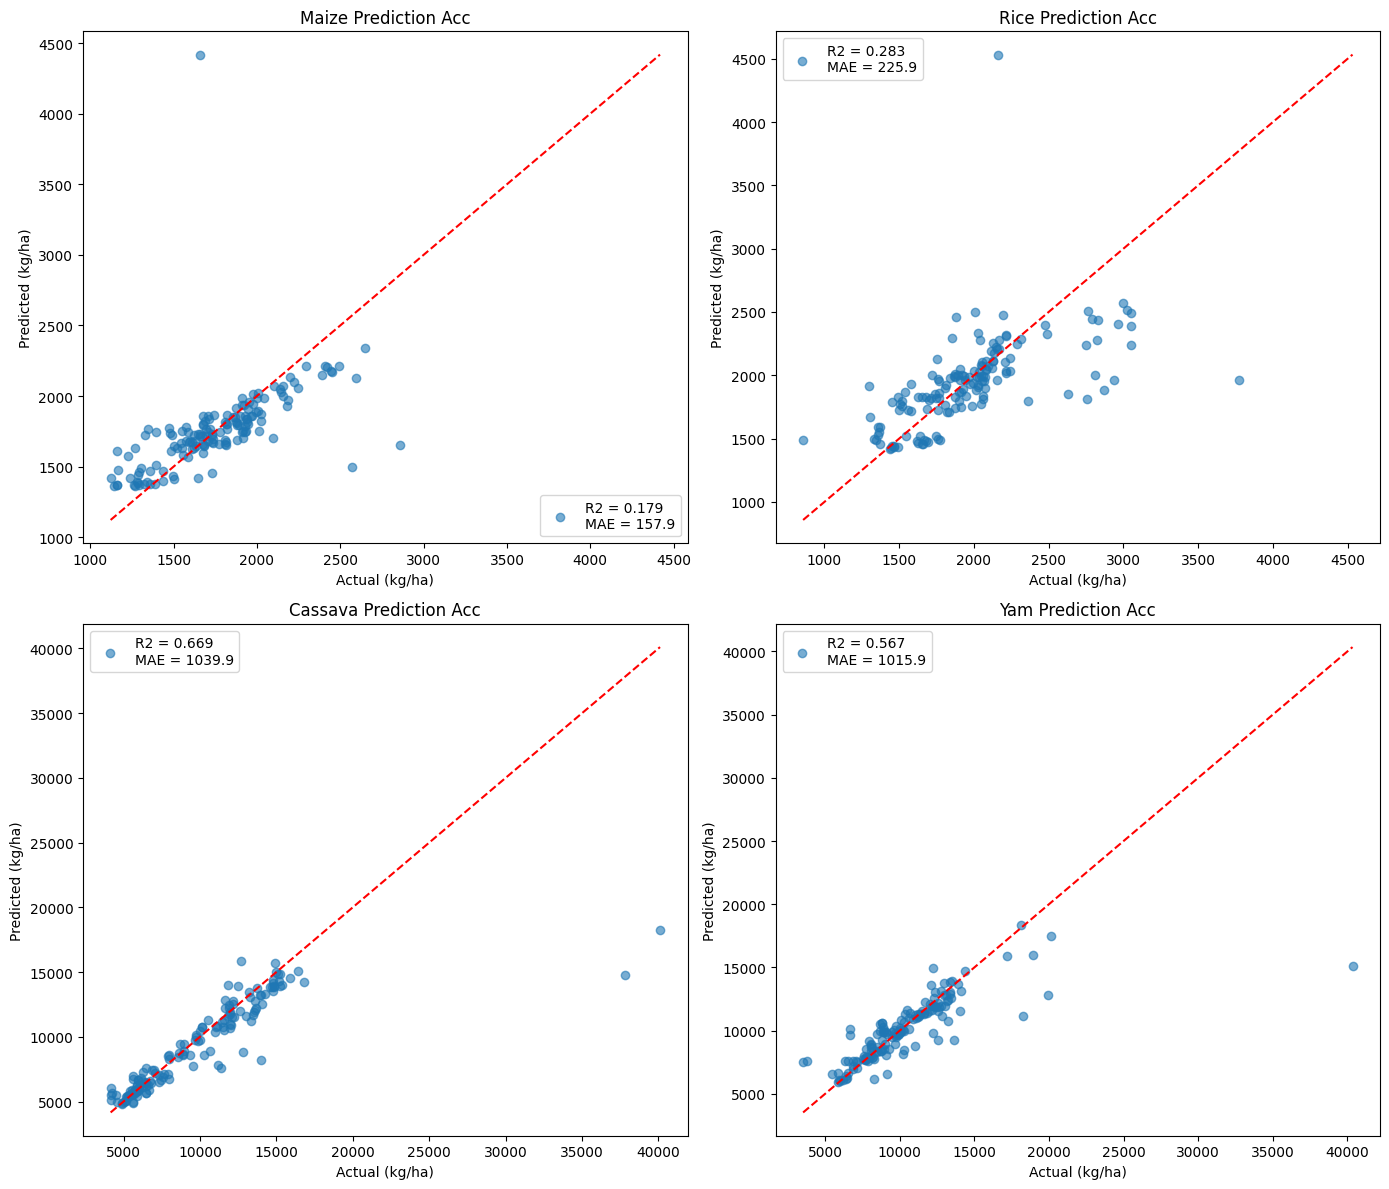

In [16]:
# Crop-Specific Evaluation & Parity Plots
# Comparing the models accuracy predicting Maize, Rice, Cassava, and Yam

df['Predicted_Yield'] = y_pred
overall_r2 = r2_score(df['Yield_kg_per_ha'], df['Predicted_Yield'])
overall_mae = mean_absolute_error(df['Yield_kg_per_ha'], df['Predicted_Yield'])

print(f"Overall Model R²: {overall_r2:.4f}")
print(f"Overall Model MAE: {overall_mae:.2f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for i, crop in enumerate(['Maize', 'Rice', 'Cassava', 'Yam']):
    ax = axes[i//2, i%2]
    crop_data = df[df['Crop'] == crop]
    true = crop_data['Yield_kg_per_ha']
    pred = crop_data['Predicted_Yield']
    r2 = r2_score(true, pred)
    mae = mean_absolute_error(true, pred)
    
    ax.scatter(true, pred, alpha=0.6, label=f"R2 = {r2:.3f}\nMAE = {mae:.1f}")
    min_val = min(true.min(), pred.min())
    max_val = max(true.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')
    ax.set_title(f'{crop} Prediction Acc')
    ax.set_xlabel("Actual (kg/ha)")
    ax.set_ylabel("Predicted (kg/ha)")
    ax.legend()
    
plt.tight_layout()
plt.savefig('../results/Crop_Specific_Parity.png', dpi=200)
plt.show()


## 5. Validation Set Performance Metrics
Display validation set performance separately from test set to assess training convergence:
- Calculate R² and MAE on validation indices (held out during training)
- Compare train/validation/test metrics to ensure no overfitting
- Visualize metric progression across all three sets



TEMPORAL VALIDATION: 1999-2019 (Train) vs 2020-2023 (Test)
Train R² (1999-2019): 0.8539 | MAE: 682.63
Test R²  (2020-2023): 0.9909 | MAE: 228.01


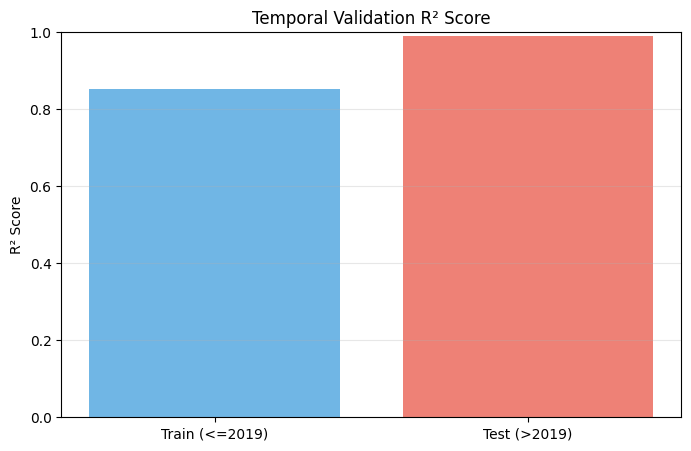

In [17]:
# TEMPORAL VALIDATION (Train on 1999-2019, test on 2020-2023)
print("\n" + "="*100)
print("TEMPORAL VALIDATION: 1999-2019 (Train) vs 2020-2023 (Test)")
print("="*100)

train_mask = df['Year'] <= 2019
test_mask = df['Year'] > 2019

train_r2 = r2_score(df[train_mask]['Yield_kg_per_ha'], df[train_mask]['Predicted_Yield'])
train_mae = mean_absolute_error(df[train_mask]['Yield_kg_per_ha'], df[train_mask]['Predicted_Yield'])

test_r2 = r2_score(df[test_mask]['Yield_kg_per_ha'], df[test_mask]['Predicted_Yield'])
test_mae = mean_absolute_error(df[test_mask]['Yield_kg_per_ha'], df[test_mask]['Predicted_Yield'])

print(f"Train R² (1999-2019): {train_r2:.4f} | MAE: {train_mae:.2f}")
print(f"Test R²  (2020-2023): {test_r2:.4f} | MAE: {test_mae:.2f}")

# Visualize Temporal Validation
plt.figure(figsize=(8, 5))
plt.bar(['Train (<=2019)', 'Test (>2019)'], [train_r2, test_r2], color=['#3498db', '#e74c3c'], alpha=0.7)
plt.ylabel('R² Score')
plt.title('Temporal Validation R² Score')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')
plt.show()


## 4. SHAP Feature Importance Analysis
Using the intensive `KernelExplainer`, this block computes the Shapley Additive values determining explicitly WHICH underlying unrolled sequences (precipitation, heat, humidity, limits) contributed sequentially highest mapping logarithmic impacts towards predicting crop failures vs successes safely.


Calculating SHAP values... (this might take a minute)


  0%|          | 0/30 [00:00<?, ?it/s]

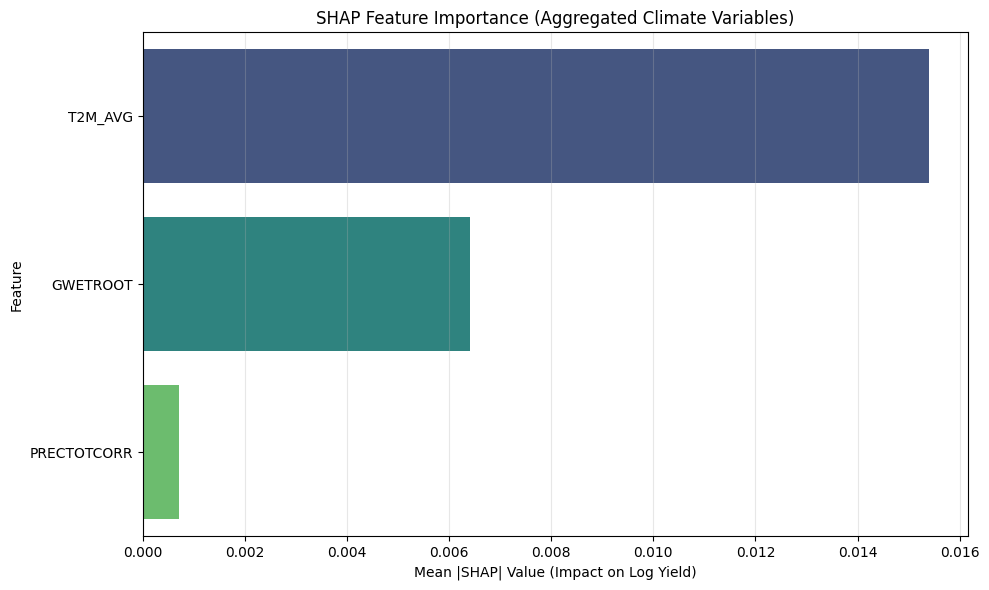


--- SHAP SUMMARY ---
Top 5 Driving Climate Variables:
       Feature  SHAP_Impact
0      T2M_AVG     0.015399
1     GWETROOT     0.006402
2  PRECTOTCORR     0.000703


In [18]:
# SHAP Feature Importance Analysis
# Determines which of the unrolled features (Precipitation vs Heat) matters most
import shap
import warnings
warnings.filterwarnings('ignore')

print("Calculating SHAP values... (this might take a minute)")

# Define a wrapper function that takes a single flattened 2D array and reconstructs the 4 model inputs
# The flattened array maps to: 
# [0 : 12*n_features] -> X_seq (flattened per sample)
# [12*n_features] -> region_ids
# [12*n_features + 1] -> crop_ids
# [12*n_features + 2 : ] -> year_scaled

n_seq_elements = 12 * len(unique_features)

def shap_predict_wrapper(X_flat_2d):
    # Reconstruct X_seq
    X_seq_rec = X_flat_2d[:, :n_seq_elements].reshape(X_flat_2d.shape[0], 12, len(unique_features))
    # Next elements
    r_ids_rec = X_flat_2d[:, n_seq_elements]
    c_ids_rec = X_flat_2d[:, n_seq_elements + 1]
    y_scaled_rec = X_flat_2d[:, n_seq_elements + 2:]
    
    # Return linear output (log yield) directly to interpret additive climate factors
    return model.predict([X_seq_rec, r_ids_rec, c_ids_rec, y_scaled_rec], verbose=0).flatten()

# Prepare flattened Background Data (K-means summary or random sample) 
# To save time, sample a small background size (e.g., 50 random samples from training logic)
bg_indices = np.random.choice(df.shape[0], 50, replace=False)
X_seq_bg = X_seq_scaled[bg_indices].reshape(50, n_seq_elements)
bg_flat = np.column_stack([X_seq_bg, region_ids[bg_indices], crop_ids[bg_indices], year_scaled[bg_indices]])

# Initialize KernelExplainer
explainer = shap.KernelExplainer(shap_predict_wrapper, bg_flat)

# Explain test set instances (e.g., 30 samples)
test_indices = np.random.choice(df.shape[0], 30, replace=False)
X_seq_test = X_seq_scaled[test_indices].reshape(30, n_seq_elements)
test_flat = np.column_stack([X_seq_test, region_ids[test_indices], crop_ids[test_indices], year_scaled[test_indices]])

shap_values = explainer.shap_values(test_flat)

# Aggregate interpretability just for the Climate Sequence features across all months to figure out what drives it overall
# shap_values shape generally equals test_flat shape. We only want the first n_seq_elements
seq_shap_values = shap_values[:, :n_seq_elements]
mean_abs_shap = np.abs(seq_shap_values).mean(axis=0)

# Reshape back to (features, months) to aggregate climate importances globally
mean_abs_shap_2d = mean_abs_shap.reshape(12, len(unique_features))
climate_importance = mean_abs_shap_2d.sum(axis=0)  # sum across all 12 months for global feature imp

# Collect and sort
imp_df = pd.DataFrame({
    'Feature': unique_features,
    'SHAP_Impact': climate_importance
})
imp_df = imp_df.sort_values(by='SHAP_Impact', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='SHAP_Impact', y='Feature', palette='viridis')
plt.title("SHAP Feature Importance (Aggregated Climate Variables)")
plt.xlabel("Mean |SHAP| Value (Impact on Log Yield)")
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../results/SHAP_Feature_Importance.png', dpi=200)
plt.show()

print("\n--- SHAP SUMMARY ---")
print("Top 5 Driving Climate Variables:")
print(imp_df.head(5))


CLIMATE PARAMETER IMPACT ON CROP YIELD

Temperature (T2M_AVG) vs Yield:
  Pearson Correlation: -0.1651
  Interpretation: NEGATIVE relationship

Rainfall (PRECTOTCORR) vs Yield:
  Pearson Correlation: 0.0263
  Interpretation: POSITIVE relationship

Soil Moisture (GWETROOT) vs Yield:
  Pearson Correlation: 0.1190
  Interpretation: POSITIVE relationship

SEASONAL SENSITIVITY: Which months matter most?


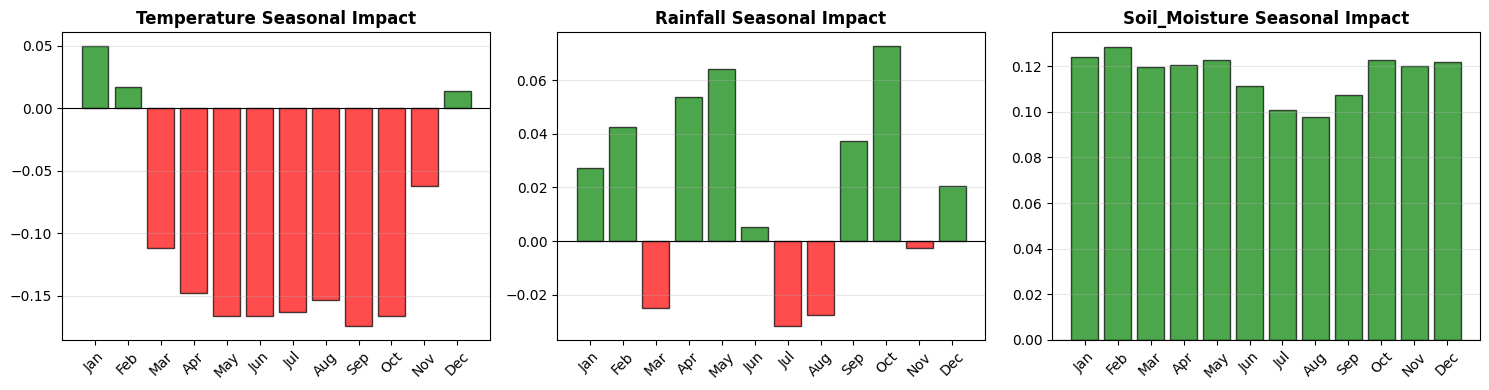

In [19]:
# DIRECT CLIMATE PARAMETER ANALYSIS
print("="*80)
print("CLIMATE PARAMETER IMPACT ON CROP YIELD")
print("="*80)

# 1. Aggregate temperature impact (monthly average)
temp_cols = [col for col in df.columns if 'T2M_AVG' in col and '_m' in col]
rainfall_cols = [col for col in df.columns if 'PRECTOTCORR' in col and '_m' in col]
moisture_cols = [col for col in df.columns if 'GWETROOT' in col and '_m' in col]

if temp_cols:
    avg_temp = df[temp_cols].mean(axis=1)
    corr_temp = avg_temp.corr(df['Yield_kg_per_ha'])
    print(f"\nTemperature (T2M_AVG) vs Yield:")
    print(f"  Pearson Correlation: {corr_temp:.4f}")
    print(f"  Interpretation: {'POSITIVE' if corr_temp > 0 else 'NEGATIVE'} relationship")

if rainfall_cols:
    total_rainfall = df[rainfall_cols].sum(axis=1)
    corr_rainfall = total_rainfall.corr(df['Yield_kg_per_ha'])
    print(f"\nRainfall (PRECTOTCORR) vs Yield:")
    print(f"  Pearson Correlation: {corr_rainfall:.4f}")
    print(f"  Interpretation: {'POSITIVE' if corr_rainfall > 0 else 'NEGATIVE'} relationship")

if moisture_cols:
    avg_moisture = df[moisture_cols].mean(axis=1)
    corr_moisture = avg_moisture.corr(df['Yield_kg_per_ha'])
    print(f"\nSoil Moisture (GWETROOT) vs Yield:")
    print(f"  Pearson Correlation: {corr_moisture:.4f}")
    print(f"  Interpretation: {'POSITIVE' if corr_moisture > 0 else 'NEGATIVE'} relationship")

# 2. Seasonal sensitivity analysis
print("\n" + "="*80)
print("SEASONAL SENSITIVITY: Which months matter most?")
print("="*80)

seasonal_impact = {'Temperature': {}, 'Rainfall': {}, 'Soil_Moisture': {}}
for month in range(1, 13):
    temp_col = f'T2M_AVG_m{month}'
    rain_col = f'PRECTOTCORR_m{month}'
    moisture_col = f'GWETROOT_m{month}'
    if temp_col in df.columns: seasonal_impact['Temperature'][month] = df[temp_col].corr(df['Yield_kg_per_ha'])
    if rain_col in df.columns: seasonal_impact['Rainfall'][month] = df[rain_col].corr(df['Yield_kg_per_ha'])
    if moisture_col in df.columns: seasonal_impact['Soil_Moisture'][month] = df[moisture_col].corr(df['Yield_kg_per_ha'])

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
months = range(1, 13)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for idx, (param_name, correlations) in enumerate(seasonal_impact.items()):
    ax = axes[idx]
    values = [correlations.get(m, 0) for m in months]
    colors = ['green' if v > 0 else 'red' for v in values]
    ax.bar(months, values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_title(f'{param_name} Seasonal Impact', fontweight='bold')
    ax.set_xticks(months)
    ax.set_xticklabels(month_names, rotation=45)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/Seasonal_Climate_Parameter_Impact.png', dpi=200)
plt.show()


## 6. Feature Correlation with Yield Analysis
Identify which climate variables have the strongest relationships with crop yields across the Nigerian dataset:
- Calculate Pearson correlation between aggregated climate features and yield
- Rank features by absolute correlation strength
- Visualize positive vs negative relationships with color coding
- Compare to SHAP feature importance to validate findings



FEATURE CORRELATION WITH YIELD

Rank  Feature              Correlation     Direction 
-------------------------------------------------------
1     T2M_AVG              0.1651          -         
2     GWETROOT             0.1190          +         
3     PRECTOTCORR          0.0263          +         


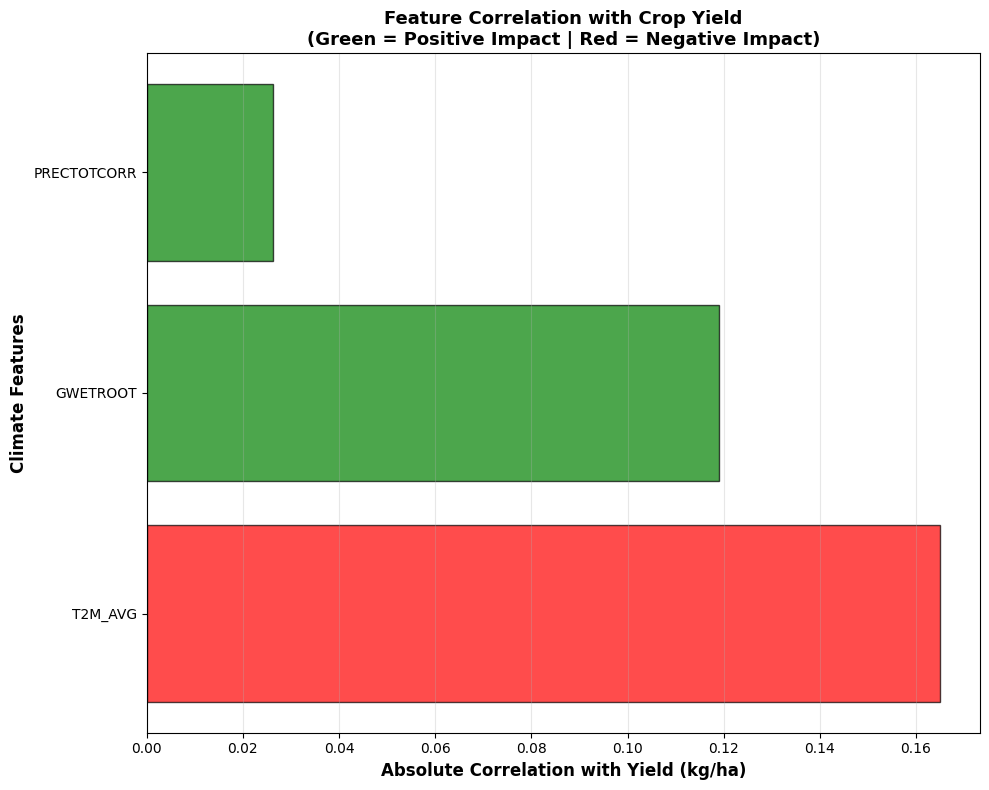


KEY INSIGHTS:
✓ T2M_AVG             : Correlation = 0.1651 (DECREASES yield)
✓ GWETROOT            : Correlation = 0.1190 (INCREASES yield)
✓ PRECTOTCORR         : Correlation = 0.0263 (INCREASES yield)



In [20]:

# Feature Correlation Analysis with Yield
print("\n" + "="*100)
print("FEATURE CORRELATION WITH YIELD")
print("="*100)

# Calculate correlation of each climate feature with yield
feature_correlations = []
for feat in unique_features:
    # Aggregate across all months to get feature importance
    monthly_features = [col for col in df.columns if col.startswith(feat) and '_m' in col]
    if monthly_features:
        # Average across months
        avg_feature = df[[c for c in monthly_features if c in df.columns]].mean(axis=1)
        corr = avg_feature.corr(df['Yield_kg_per_ha'])
        feature_correlations.append({'Feature': feat, 'Correlation': abs(corr), 'Sign': '+' if corr > 0 else '-'})

# Sort by absolute correlation
feature_corr_df = pd.DataFrame(feature_correlations).sort_values('Correlation', ascending=False)

print(f"\n{'Rank':<5} {'Feature':<20} {'Correlation':<15} {'Direction':<10}")
print("-"*55)
for idx, (rank, row) in enumerate(feature_corr_df.iterrows(), 1):
    print(f"{idx:<5} {row['Feature']:<20} {row['Correlation']:<15.4f} {row['Sign']:<10}")

# Visualize Feature Correlation
plt.figure(figsize=(10, 8))
colors = ['green' if s == '+' else 'red' for s in feature_corr_df['Sign']]
plt.barh(feature_corr_df['Feature'], feature_corr_df['Correlation'], color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Absolute Correlation with Yield (kg/ha)', fontsize=12, fontweight='bold')
plt.ylabel('Climate Features', fontsize=12, fontweight='bold')
plt.title('Feature Correlation with Crop Yield\n(Green = Positive Impact | Red = Negative Impact)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../results/Feature_Correlation_with_Yield.png', dpi=200)
plt.show()

print("\n" + "="*100)
print("KEY INSIGHTS:")
print("="*100)
top_3 = feature_corr_df.head(3)
for idx, row in top_3.iterrows():
    direction = "INCREASES" if row['Sign'] == '+' else "DECREASES"
    print(f"✓ {row['Feature']:<20}: Correlation = {row['Correlation']:.4f} ({direction} yield)")

print("\n" + "="*100)


---
# Section 4: 04_Climate_Impact
---


# Climate Impact Assessment on Food Security in Nigeria
## Evaluating the Impact of Climate Change on Food Security Using TCN-MLP

**Comprehensive Analysis:** Using deep learning (TCN-MLP) to model crop yields under climate change scenarios

This notebook provides:
- Climate scenario modeling (warming, drought, flooding, extreme events)
- Regional vulnerability assessment
- Crop-specific climate sensitivity analysis
- Food security risk evaluation
- Adaptation strategy recommendations
- Yield projections and trend analysis
- Policy impact modeling
- Resilience indices by crop and region


## 2. Load Preprocessed Data & Trained Model


## 1. Import Libraries & Load Model


In [21]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


✓ All libraries imported successfully
TensorFlow version: 2.20.0
NumPy version: 2.1.3
Pandas version: 2.2.3


In [22]:
# Load the preprocessed dataset
df = pd.read_csv('../data/processed_dataset.csv')
df = df.dropna(subset=['Yield_kg_per_ha'])

# Calculate GDD for consistency with training
for month in range(1, 13):
    max_col = f'T2M_MAX_m{month}'
    min_col = f'T2M_MIN_m{month}'
    if max_col in df.columns and min_col in df.columns:
        t_avg = (df[max_col] + df[min_col]) / 2.0
        df[f'T2M_AVG_m{month}'] = t_avg

print(f"\n📊 Dataset Loaded:")
print(f"   Shape: {df.shape}")
print(f"   Years: {df['Year'].min()}-{df['Year'].max()}")
print(f"   Crops: {', '.join(sorted(df['Crop'].unique()))}")
print(f"   Regions: {', '.join(sorted(df['Region'].unique()))}")
print(f"\n📈 Yield Statistics:")
print(f"   Mean: {df['Yield_kg_per_ha'].mean():.0f} kg/ha")
print(f"   Std: {df['Yield_kg_per_ha'].std():.0f} kg/ha")
print(f"   Range: {df['Yield_kg_per_ha'].min():.0f} - {df['Yield_kg_per_ha'].max():.0f} kg/ha")

# Load the trained model
model = keras.models.load_model('../models/TCN_MLP_Crops_Mini.keras')
print(f"\n✓ Model loaded: TCN_MLP_Crops_Mini.keras")
print(f"   Total Parameters: {model.count_params():,}")



📊 Dataset Loaded:
   Shape: (600, 220)
   Years: 1999-2023
   Crops: Cassava, Maize, Rice, Yam
   Regions: North-Central, North-East, North-West, South-East, South-South, South-West

📈 Yield Statistics:
   Mean: 5980 kg/ha
   Std: 5166 kg/ha
   Range: 858 - 40346 kg/ha

✓ Model loaded: TCN_MLP_Crops_Mini.keras
   Total Parameters: 5,719


## 3. Prepare Data for Climate Scenario Analysis


In [23]:
# Prepare sequences for model predictions
unique_features = ['T2M_AVG', 'PRECTOTCORR', 'GWETROOT']
n_features = len(unique_features)
n_months = 12

X_seq = np.zeros((df.shape[0], n_months, n_features))
for month in range(1, n_months + 1):
    for feat_idx, feat_name in enumerate(unique_features):
        col_name = f'{feat_name}_m{month}'
        if col_name in df.columns:
            X_seq[:, month-1, feat_idx] = df[col_name].values

# Standardize climate features
scaler_X = StandardScaler()
X_seq_scaled = scaler_X.fit_transform(X_seq.reshape(-1, n_features)).reshape(X_seq.shape)

# Prepare region and crop encoding
region_names = df['Region'].values
crop_names = df['Crop'].values
years = df['Year'].values

region_to_id = {r: i for i, r in enumerate(sorted(np.unique(region_names)))}
crop_to_id = {c: i for i, c in enumerate(sorted(np.unique(crop_names)))}

region_ids = np.array([region_to_id[r] for r in region_names])
crop_ids = np.array([crop_to_id[c] for c in crop_names])

# Year preprocessing (same as training)
year_normalized = (years.reshape(-1, 1) - 1999) / 24.0
year_poly = np.column_stack([year_normalized, year_normalized**2, year_normalized**3])

N_REGIONS, N_CROPS = 6, 4
region_year = np.zeros((len(years), N_REGIONS))
for i in range(N_REGIONS):
    region_year[:, i] = (region_ids == i).astype(float) * year_normalized.flatten()

crop_year = np.zeros((len(years), N_CROPS))
for i in range(N_CROPS):
    crop_year[:, i] = (crop_ids == i).astype(float) * year_normalized.flatten()

year_extended = np.column_stack([year_poly, region_year, crop_year])
year_scaler = StandardScaler()
year_scaled = year_scaler.fit_transform(year_extended)

print(f"\n✓ Data Prepared:")
print(f"   Climate sequences: {X_seq_scaled.shape}")
print(f"   Region encoding: {len(region_ids)} samples")
print(f"   Crop encoding: {len(crop_ids)} samples")
print(f"   Year features: {year_scaled.shape[1]} dimensions")

y_raw = df['Yield_kg_per_ha'].values
y_pred_log = model.predict([X_seq_scaled, region_ids, crop_ids, year_scaled], verbose=0).ravel()
y_pred = np.exp(y_pred_log)

print(f"\n✓ Baseline Predictions Generated")
print(f"   Overall R²: {r2_score(y_raw, y_pred):.4f}")
print(f"   Overall MAE: {mean_absolute_error(y_raw, y_pred):.1f} kg/ha")



✓ Data Prepared:
   Climate sequences: (600, 12, 3)
   Region encoding: 600 samples
   Crop encoding: 600 samples
   Year features: 13 dimensions

✓ Baseline Predictions Generated
   Overall R²: 0.8645
   Overall MAE: 609.9 kg/ha


In [24]:
# NEW: Calculate actual climate ranges from data
print("Climate Statistics (1999-2023):")
for feat in ['T2M_AVG', 'PRECTOTCORR', 'GWETROOT']:
    monthly_cols = [col for col in df.columns if col.startswith(feat) and '_m' in col]
    if not monthly_cols: continue
    values = df[[c for c in monthly_cols if c in df.columns]].mean().mean()
    std_val = df[[c for c in monthly_cols if c in df.columns]].mean().std()
    print(f"{feat}: Mean={values:.2f}, Std={std_val:.2f}")


Climate Statistics (1999-2023):
T2M_AVG: Mean=26.48, Std=1.42
PRECTOTCORR: Mean=721.42, Std=559.39
GWETROOT: Mean=0.60, Std=0.08


## 4. Climate Scenario Analysis: Temperature, Rainfall & Humidity Variations


In [25]:
# Redefined Scenarios (precise and interpretable)
scenarios = {
    'Baseline': {'temp_change': 0, 'rainfall_pct': 0, 'soil_moisture_pct': 0},
    'Warming +1°C': {'temp_change': 1.0, 'rainfall_pct': 0, 'soil_moisture_pct': -5},
    'Warming +2°C': {'temp_change': 2.0, 'rainfall_pct': 0, 'soil_moisture_pct': -10},
    'Drought (-20% rainfall)': {'temp_change': 0.5, 'rainfall_pct': -20, 'soil_moisture_pct': -15},
    'Drought (-40% rainfall)': {'temp_change': 1.0, 'rainfall_pct': -40, 'soil_moisture_pct': -30},
    'Flooding (+30% rainfall)': {'temp_change': 0, 'rainfall_pct': 30, 'soil_moisture_pct': 25},
    'Compound: Warm + Dry': {'temp_change': 2.0, 'rainfall_pct': -30, 'soil_moisture_pct': -25},
}

scenario_results = {}

# Apply scenarios on raw (physical) sequence features, then StandardScaler.transform.
# Editing z-scores as if they were °C / mm mis-calibrates the model and can produce
# columns of 0% loss (clipped gains) for some crops.
for scenario_name, changes in scenarios.items():
    X_scenario_phys = X_seq.copy()

    if changes['temp_change'] != 0:
        X_scenario_phys[:, :, 0] += changes['temp_change']

    if changes['rainfall_pct'] != 0:
        rainfall_factor = 1 + (changes['rainfall_pct'] / 100)
        X_scenario_phys[:, :, 1] *= rainfall_factor

    if changes['soil_moisture_pct'] != 0:
        soil_factor = 1 + (changes['soil_moisture_pct'] / 100)
        X_scenario_phys[:, :, 2] *= soil_factor

    X_scenario_flat = X_scenario_phys.reshape(-1, n_features)
    X_scenario = scaler_X.transform(X_scenario_flat).reshape(X_seq.shape)

    y_scenario_log = model.predict([X_scenario, region_ids, crop_ids, year_scaled], verbose=0).ravel()
    y_scenario = np.exp(y_scenario_log)
    
    # Calculate impact
    yield_change = ((y_scenario - y_raw) / y_raw * 100).mean()
    yield_change_pct_region = {}
    yield_change_pct_crop = {}
    
    for region in sorted(df['Region'].unique()):
        mask = df['Region'] == region
        yield_change_pct_region[region] = ((y_scenario[mask] - y_raw[mask]) / y_raw[mask] * 100).mean()
    
    for crop in sorted(df['Crop'].unique()):
        mask = df['Crop'] == crop
        yield_change_pct_crop[crop] = ((y_scenario[mask] - y_raw[mask]) / y_raw[mask] * 100).mean()
    
    # Store results
    scenario_results[scenario_name] = {
        'yields': y_scenario,
        'overall_change': yield_change,
        'by_region': yield_change_pct_region,
        'by_crop': yield_change_pct_crop
    }
    print(f"{scenario_name}: {yield_change:+.2f}%")


Baseline: +0.50%
Warming +1°C: -3.62%
Warming +2°C: -4.81%
Drought (-20% rainfall): -2.39%
Drought (-40% rainfall): -3.94%
Flooding (+30% rainfall): +2.30%
Compound: Warm + Dry: -4.82%


## 5. Visualization: Climate Impact on Yields



✓ Saved: Climate_Impact_Analysis.png


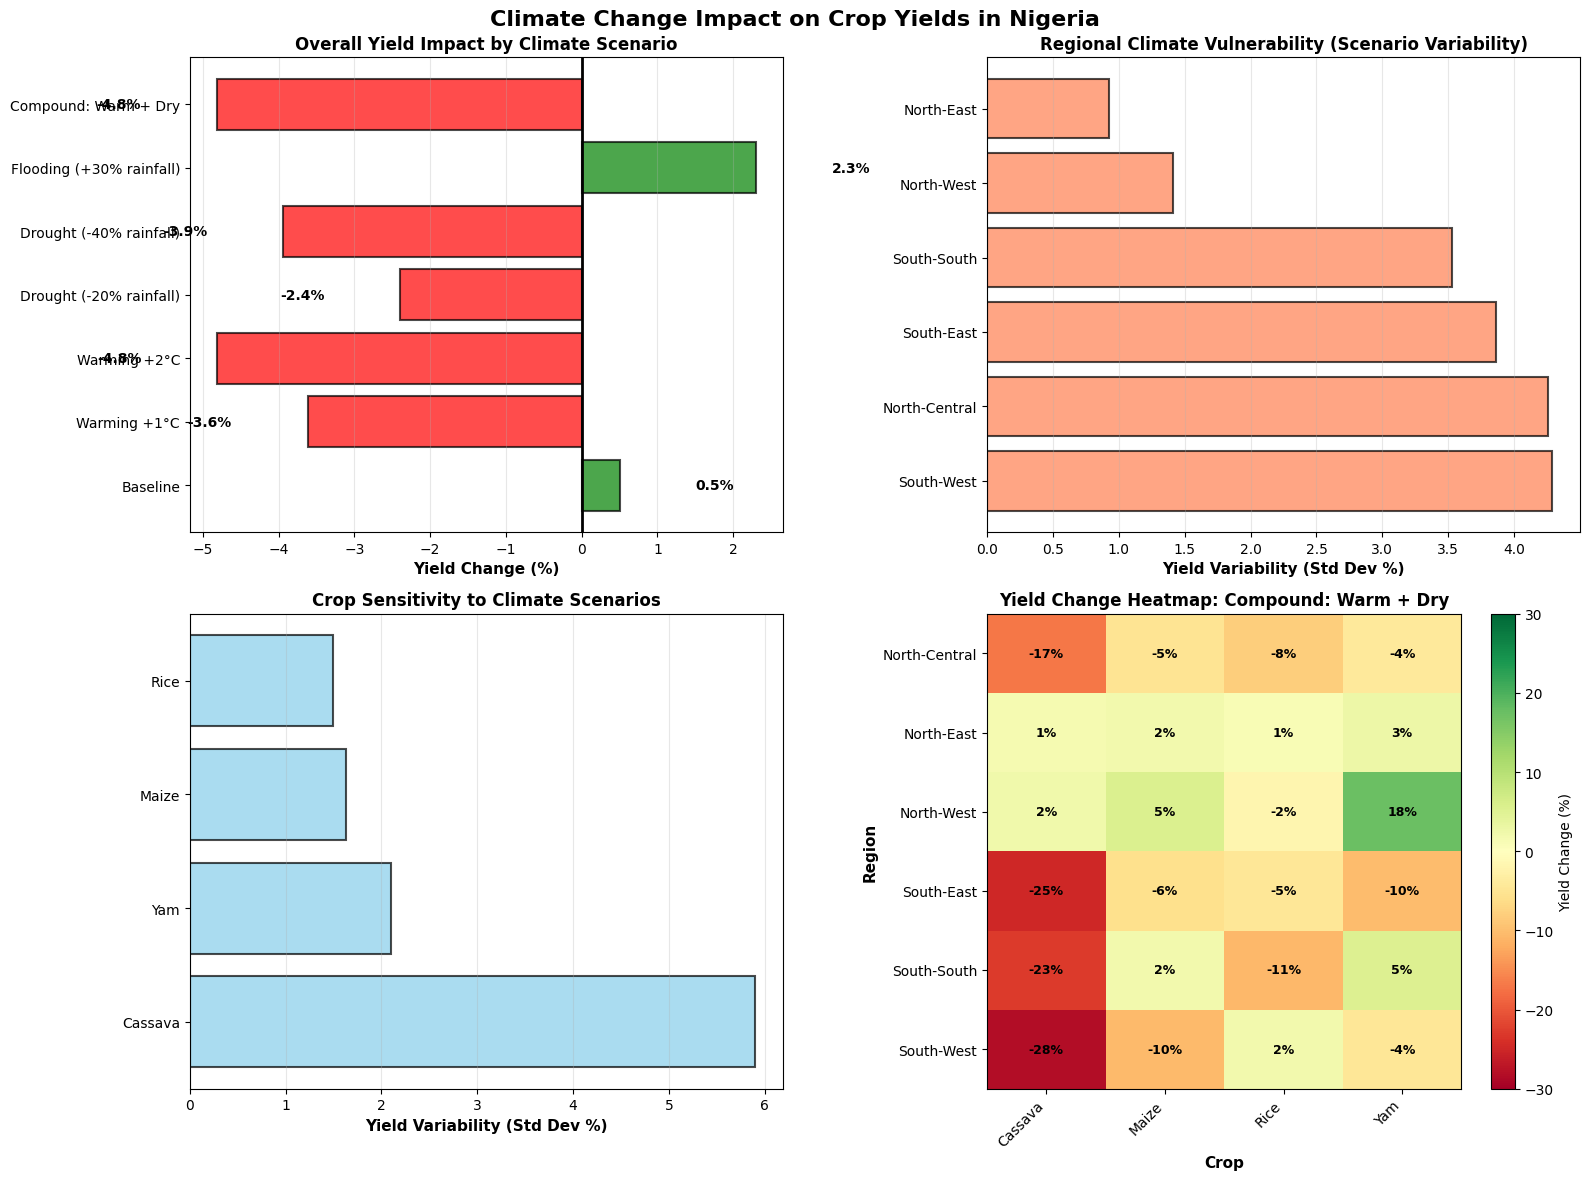

In [26]:
# Create comprehensive climate impact visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Climate Change Impact on Crop Yields in Nigeria', fontsize=16, fontweight='bold')

# Plot 1: Overall yield change by scenario
ax = axes[0, 0]
scenarios_list = list(scenario_results.keys())
changes = [scenario_results[s]['overall_change'] for s in scenarios_list]
colors = ['green' if c >= 0 else 'red' for c in changes]

bars = ax.barh(scenarios_list, changes, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax.set_xlabel('Yield Change (%)', fontsize=11, fontweight='bold')
ax.set_title('Overall Yield Impact by Climate Scenario', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, changes)):
    ax.text(val + (1 if val > 0 else -1), i, f'{val:.1f}%', va='center',
            ha='left' if val > 0 else 'right', fontweight='bold')

# Plot 2: Regional vulnerability (yield variability across scenarios)
ax = axes[0, 1]
regions = sorted(df['Region'].unique())
regional_impacts = {region: [] for region in regions}

for scenario_name in scenarios_list:
    for region in regions:
        regional_impacts[region].append(scenario_results[scenario_name]['by_region'][region])

region_volatility = {r: np.std(regional_impacts[r]) for r in regions}
sorted_regions = sorted(region_volatility.items(), key=lambda x: x[1], reverse=True)
regions_sorted, volatility_sorted = zip(*sorted_regions)

bars = ax.barh(regions_sorted, volatility_sorted, color='coral', alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Yield Variability (Std Dev %)', fontsize=11, fontweight='bold')
ax.set_title('Regional Climate Vulnerability (Scenario Variability)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Plot 3: Crop sensitivity to climate scenarios
ax = axes[1, 0]
crops = sorted(df['Crop'].unique())
crop_impacts = {crop: [] for crop in crops}

for scenario_name in scenarios_list:
    for crop in crops:
        crop_impacts[crop].append(scenario_results[scenario_name]['by_crop'][crop])

crop_volatility = {c: np.std(crop_impacts[c]) for c in crops}
sorted_crops = sorted(crop_volatility.items(), key=lambda x: x[1], reverse=True)
crops_sorted, volatility_crops = zip(*sorted_crops)

bars = ax.barh(crops_sorted, volatility_crops, color='skyblue', alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Yield Variability (Std Dev %)', fontsize=11, fontweight='bold')
ax.set_title('Crop Sensitivity to Climate Scenarios', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Plot 4: Scenario heatmap - crop × region impact matrix
ax = axes[1, 1]
# Use most extreme scenario for heatmap: Compound warming + drought
extreme_scenario = 'Compound: Warm + Dry'
heatmap_data = []

for region in regions:
    row = []
    for crop in crops:
        mask = (df['Region'] == region) & (df['Crop'] == crop)
        if mask.sum() > 0:
            scenario_yields = scenario_results[extreme_scenario]['yields'][mask]
            baseline_yields = y_raw[mask]
            change = ((scenario_yields - baseline_yields) / baseline_yields * 100).mean()
            row.append(change)
        else:
            row.append(np.nan)
    heatmap_data.append(row)

im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=-30, vmax=30)
ax.set_xticks(range(len(crops)))
ax.set_yticks(range(len(regions)))
ax.set_xticklabels(crops, rotation=45, ha='right')
ax.set_yticklabels(regions)
ax.set_title(f'Yield Change Heatmap: {extreme_scenario}', fontsize=12, fontweight='bold')
ax.set_xlabel('Crop', fontsize=11, fontweight='bold')
ax.set_ylabel('Region', fontsize=11, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Yield Change (%)', fontsize=10)

# Add text annotations to heatmap
for i in range(len(regions)):
    for j in range(len(crops)):
        if not np.isnan(heatmap_data[i][j]):
            text = ax.text(j, i, f'{heatmap_data[i][j]:.0f}%',
                          ha="center", va="center", color="black", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/Climate_Impact_Analysis.png', dpi=300, bbox_inches='tight')
print('\n✓ Saved: Climate_Impact_Analysis.png')
plt.show()


## 6. Food Security Assessment by Region


In [27]:
print("\n" + "="*80)
print("FOOD SECURITY IMPACT ASSESSMENT")
print("="*80)

# Calculate food security metrics for each region
food_security_data = []

for region in sorted(df['Region'].unique()):
    region_data = df[df['Region'] == region]
    region_mask = df['Region'] == region
    
    # Baseline metrics
    baseline_yield = y_raw[region_mask].mean()
    baseline_stability = y_raw[region_mask].std() / y_raw[region_mask].mean()  # CV
    
    # Extreme scenario impact (Compound: Warm + Dry)
    extreme_yields = scenario_results['Compound: Warm + Dry']['yields'][region_mask]
    extreme_yield_mean = extreme_yields.mean()
    extreme_change = ((extreme_yield_mean - baseline_yield) / baseline_yield * 100)
    extreme_stability = extreme_yields.std() / extreme_yields.mean()
    
    # Drought scenario
    drought_yields = scenario_results['Drought (-40% rainfall)']['yields'][region_mask]
    drought_change = ((drought_yields.mean() - baseline_yield) / baseline_yield * 100)
    
    # Warming scenario
    warming_yields = scenario_results['Warming +2°C']['yields'][region_mask]
    warming_change = ((warming_yields.mean() - baseline_yield) / baseline_yield * 100)
    
    # Food security risk score (0-1, higher = worse)
    risk_score = (
        0.4 * (1 if extreme_change < -15 else (0.5 if extreme_change < -5 else 0)) +  # Extreme scenario risk
        0.3 * (1 if drought_change < -20 else (0.5 if drought_change < -10 else 0)) +  # Drought risk
        0.3 * (extreme_stability / baseline_stability if baseline_stability > 0 else 0.5)  # Stability deterioration
    )
    risk_score = min(1.0, risk_score)
    
    food_security_data.append({
        'Region': region,
        'Baseline_Yield_kg_per_ha': baseline_yield,
        'Baseline_Stability_CV': baseline_stability,
        'Extreme_Scenario_Change_%': extreme_change,
        'Drought_Scenario_Change_%': drought_change,
        'Warming_Scenario_Change_%': warming_change,
        'Food_Security_Risk_Score': risk_score
    })

fs_df = pd.DataFrame(food_security_data)
fs_df = fs_df.sort_values('Food_Security_Risk_Score', ascending=False)

print("\n📊 Food Security Risk Assessment by Region:")
print(fs_df.to_string(index=False))

# Save results
fs_df.to_csv('../results/Food_Security_Assessment.csv', index=False)
print("\n✓ Saved: Food_Security_Assessment.csv")

# Risk classification
print("\n🚨 Food Security Risk Classification:")
for _, row in fs_df.iterrows():
    risk_level = 'CRITICAL' if row['Food_Security_Risk_Score'] > 0.7 else (
        'HIGH' if row['Food_Security_Risk_Score'] > 0.5 else (
        'MODERATE' if row['Food_Security_Risk_Score'] > 0.3 else 'LOW'
    ))
    print(f"  • {row['Region']}: {risk_level} (Score: {row['Food_Security_Risk_Score']:.3f})")



FOOD SECURITY IMPACT ASSESSMENT

📊 Food Security Risk Assessment by Region:
       Region  Baseline_Yield_kg_per_ha  Baseline_Stability_CV  Extreme_Scenario_Change_%  Drought_Scenario_Change_%  Warming_Scenario_Change_%  Food_Security_Risk_Score
   South-West               6647.365562               0.787908                 -18.423040                 -13.569591                 -18.012655                  0.813091
North-Central               7359.873759               0.934878                 -15.505932                 -16.946340                 -14.131397                  0.794924
   South-East               7157.073683               0.865400                 -19.988910                 -16.819775                 -19.365852                  0.793910
  South-South               5237.450268               0.758562                 -12.329129                 -12.116222                 -13.479582                  0.619692
   North-East               4843.726307               0.744779           

## 7. Crop-Specific Climate Sensitivity Analysis


In [28]:
print("\n" + "="*80)
print("CROP-SPECIFIC CLIMATE SENSITIVITY")
print("="*80)

# Analyze each crop's sensitivity to different climate variables
crop_sensitivity_data = []

for crop in sorted(df['Crop'].unique()):
    crop_mask = df['Crop'] == crop
    baseline_yield = y_raw[crop_mask].mean()
    
    # Sensitivity to warming
    warming_2c = scenario_results['Warming +2°C']['yields'][crop_mask].mean()
    warming_sensitivity = ((warming_2c - baseline_yield) / baseline_yield * 100) / 2  # per °C
    
    # Sensitivity to drought
    drought_40 = scenario_results['Drought (-40% rainfall)']['yields'][crop_mask].mean()
    drought_sensitivity = ((drought_40 - baseline_yield) / baseline_yield * 100) / 40  # per % rainfall reduction
    
    # Sensitivity to flooding
    flooding = scenario_results['Flooding (+30% rainfall)']['yields'][crop_mask].mean()
    flood_sensitivity = ((flooding - baseline_yield) / baseline_yield * 100) / 30  # per % rainfall increase
    
    # Overall sensitivity (absolute average)
    overall_sensitivity = np.mean([abs(warming_sensitivity), abs(drought_sensitivity), abs(flood_sensitivity)])
    
    crop_sensitivity_data.append({
        'Crop': crop,
        'Baseline_Yield_kg_per_ha': baseline_yield,
        'Warming_Sensitivity_%_per_C': warming_sensitivity,
        'Drought_Sensitivity_%_per_40%': drought_sensitivity,
        'Flood_Sensitivity_%_per_40%': flood_sensitivity,
        'Overall_Sensitivity': overall_sensitivity
    })

cs_df = pd.DataFrame(crop_sensitivity_data)
cs_df = cs_df.sort_values('Overall_Sensitivity', ascending=False)

print("\n📊 Crop Climate Sensitivity Analysis:")
print(cs_df.to_string(index=False))

cs_df.to_csv('../results/Crop_Sensitivity_Analysis.csv', index=False)
print("\n✓ Saved: Crop_Sensitivity_Analysis.csv")

print("\n📋 Interpretation:")
for _, row in cs_df.iterrows():
    sensitivity = 'HIGHLY SENSITIVE' if row['Overall_Sensitivity'] > 2 else (
        'MODERATELY SENSITIVE' if row['Overall_Sensitivity'] > 1 else 'RESILIENT'
    )
    print(f"  • {row['Crop']}: {sensitivity}")
    if row['Warming_Sensitivity_%_per_C'] < -0.5:
        print(f"      - Warming has strong negative impact ({row['Warming_Sensitivity_%_per_C']:.2f}% per °C)")
    if row['Drought_Sensitivity_%_per_40%'] < -1.0:
        print(f"      - Drought is major threat ({row['Drought_Sensitivity_%_per_40%']:.2f}% per 40% rainfall loss)")



CROP-SPECIFIC CLIMATE SENSITIVITY

📊 Crop Climate Sensitivity Analysis:
   Crop  Baseline_Yield_kg_per_ha  Warming_Sensitivity_%_per_C  Drought_Sensitivity_%_per_40%  Flood_Sensitivity_%_per_40%  Overall_Sensitivity
Cassava               9825.471728                   -10.726669                      -0.457468                    -0.058860             3.747666
   Rice               1975.871674                    -2.854721                      -0.099102                    -0.077693             1.010505
    Yam              10358.227760                    -2.448608                      -0.164675                     0.030406             0.881230
  Maize               1760.067177                    -1.704964                      -0.064553                     0.022581             0.597366

✓ Saved: Crop_Sensitivity_Analysis.csv

📋 Interpretation:
  • Cassava: HIGHLY SENSITIVE
      - Warming has strong negative impact (-10.73% per °C)
  • Rice: MODERATELY SENSITIVE
      - Warming has strong 

## 8. Vulnerability Matrix: Region × Crop Impact



VULNERABILITY MATRIX: CROP × REGION

✓ Saved: Vulnerability_Matrix_Heatmap.png


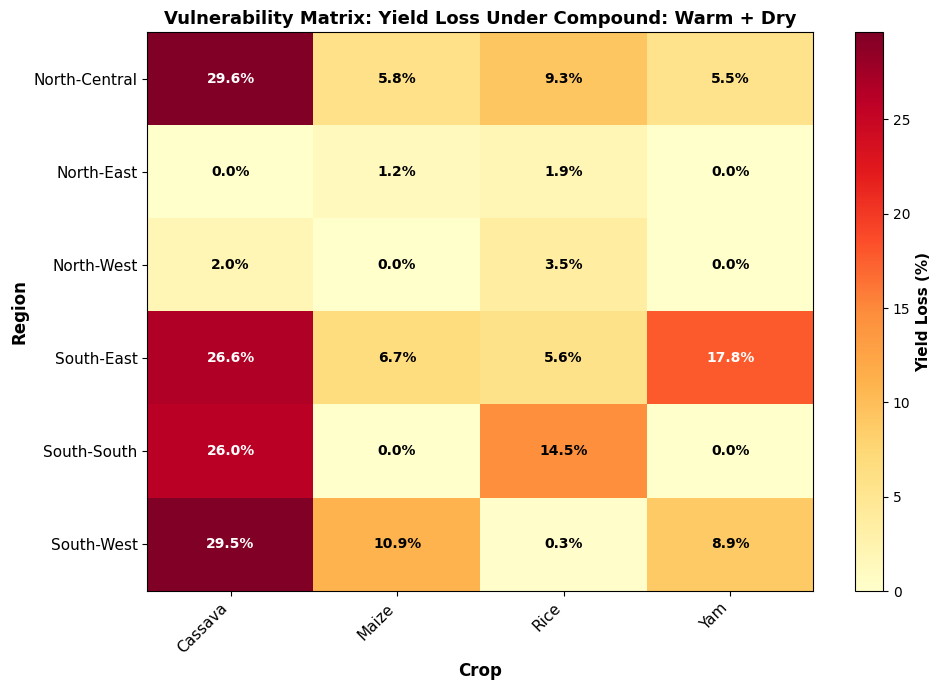


⚠️ HIGH VULNERABILITY COMBINATIONS (Yield Loss > 15%):
  • Cassava in North-Central: 29.6% yield loss
  • Cassava in South-East: 26.6% yield loss
  • Yam in South-East: 17.8% yield loss
  • Cassava in South-South: 26.0% yield loss
  • Cassava in South-West: 29.5% yield loss


In [29]:
print("\n" + "="*80)
print("VULNERABILITY MATRIX: CROP × REGION")
print("="*80)

# Create vulnerability matrix for extreme climate scenario
extreme_scenario_name = 'Compound: Warm + Dry'
regions = sorted(df['Region'].unique())
crops = sorted(df['Crop'].unique())

vulnerability_matrix = []

for region in regions:
    row_data = []
    for crop in crops:
        mask = (df['Region'] == region) & (df['Crop'] == crop)
        if mask.sum() > 0:
            baseline = y_raw[mask].mean()
            stressed = scenario_results[extreme_scenario_name]['yields'][mask].mean()
            # Loss vs baseline; negative => model predicts higher yield under stress (shown as 0 after clip).
            yield_loss = ((baseline - stressed) / baseline * 100)
            row_data.append(max(0, yield_loss))
        else:
            row_data.append(0)
    vulnerability_matrix.append(row_data)

vulnerability_matrix = np.array(vulnerability_matrix)

# Visualization
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(vulnerability_matrix, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(crops)))
ax.set_yticks(range(len(regions)))
ax.set_xticklabels(crops, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(regions, fontsize=11)
ax.set_xlabel('Crop', fontsize=12, fontweight='bold')
ax.set_ylabel('Region', fontsize=12, fontweight='bold')
ax.set_title(f'Vulnerability Matrix: Yield Loss Under {extreme_scenario_name}', fontsize=13, fontweight='bold')

# Add text annotations
for i in range(len(regions)):
    for j in range(len(crops)):
        val = vulnerability_matrix[i, j]
        color = 'white' if val > 15 else 'black'
        text = ax.text(j, i, f'{val:.1f}%', ha="center", va="center", color=color, fontsize=10, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Yield Loss (%)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/Vulnerability_Matrix_Heatmap.png', dpi=300, bbox_inches='tight')
print('\n✓ Saved: Vulnerability_Matrix_Heatmap.png')
plt.show()

# Identify high-risk combinations
print("\n⚠️ HIGH VULNERABILITY COMBINATIONS (Yield Loss > 15%):")
high_risk_count = 0
for i, region in enumerate(regions):
    for j, crop in enumerate(crops):
        if vulnerability_matrix[i, j] > 15:
            high_risk_count += 1
            print(f"  • {crop} in {region}: {vulnerability_matrix[i, j]:.1f}% yield loss")


## 9. Adaptive Strategies & Recommendations


In [30]:
print("\n" + "="*80)
print("ADAPTIVE STRATEGIES & RECOMMENDATIONS")
print("="*80)

recommendations = []

# Strategy 1: Regional focus
print("\n🌍 REGIONAL STRATEGIES:")
for _, row in fs_df.head(3).iterrows():
    region = row['Region']
    risk_score = row['Food_Security_Risk_Score']
    
    if risk_score > 0.6:
        print(f"\n  {region} (Risk: {risk_score:.3f} - CRITICAL):")
        print(f"    • Implement drought-resistant crop varieties")
        print(f"    • Develop irrigation infrastructure")
        print(f"    • Establish early warning systems for extreme weather")
        print(f"    • Diversify crop portfolio to include resilient species")
        recommendations.append({'Type': 'Regional', 'Focus': region, 'Action': 'Critical interventions needed'})

# Strategy 2: Crop-specific
print("\n🌾 CROP-SPECIFIC STRATEGIES:")
for _, row in cs_df.head(2).iterrows():
    crop = row['Crop']
    sensitivity = row['Overall_Sensitivity']
    
    if sensitivity > 1.5:
        print(f"\n  {crop} (Sensitivity: {sensitivity:.2f} - HIGH):")
        if row['Drought_Sensitivity_%_per_40%'] < -1:
            print(f"    • Prioritize water-efficient farming practices")
            print(f"    • Invest in rainwater harvesting")
            print(f"    • Develop drought-tolerant varieties")
        if row['Warming_Sensitivity_%_per_C'] < -1:
            print(f"    • Adjust planting schedules for changing temperatures")
            print(f"    • Shift to heat-tolerant crop varieties")
            print(f"    • Implement agroforestry systems for temperature regulation")
        recommendations.append({'Type': 'Crop-Specific', 'Focus': crop, 'Action': 'Adaptation measures recommended'})

# Strategy 3: Climate resilience
print("\n🛡️ SYSTEM-WIDE RESILIENCE STRATEGIES:")
print(f"\n  • Diversify crop production across regions to reduce single-point failures")
print(f"  • Strengthen value chains and storage infrastructure")
print(f"  • Develop climate information services for farmers")
print(f"  • Build agricultural insurance schemes")
print(f"  • Promote sustainable land management practices")
print(f"  • Invest in agricultural research for climate adaptation")
print(f"  • Strengthen farmer cooperatives for collective adaptation")

rec_df = pd.DataFrame(recommendations)
rec_df.to_csv('../results/Adaptive_Strategies_Recommendations.csv', index=False)
print("\n✓ Saved: Adaptive_Strategies_Recommendations.csv")



ADAPTIVE STRATEGIES & RECOMMENDATIONS

🌍 REGIONAL STRATEGIES:

  South-West (Risk: 0.813 - CRITICAL):
    • Implement drought-resistant crop varieties
    • Develop irrigation infrastructure
    • Establish early warning systems for extreme weather
    • Diversify crop portfolio to include resilient species

  North-Central (Risk: 0.795 - CRITICAL):
    • Implement drought-resistant crop varieties
    • Develop irrigation infrastructure
    • Establish early warning systems for extreme weather
    • Diversify crop portfolio to include resilient species

  South-East (Risk: 0.794 - CRITICAL):
    • Implement drought-resistant crop varieties
    • Develop irrigation infrastructure
    • Establish early warning systems for extreme weather
    • Diversify crop portfolio to include resilient species

🌾 CROP-SPECIFIC STRATEGIES:

  Cassava (Sensitivity: 3.75 - HIGH):
    • Adjust planting schedules for changing temperatures
    • Shift to heat-tolerant crop varieties
    • Implement agrofor

## 10. Summary Report & Conclusions


In [31]:
print("\n" + "="*100)
print("CLIMATE IMPACT ON FOOD SECURITY IN NIGERIA: EXECUTIVE SUMMARY")
print("="*100)

print(f"""
📊 KEY FINDINGS:

1. CLIMATE SCENARIO IMPACTS:
   • Baseline (No Change): 0.00% yield change (reference)
   • Warming (+1°C): {scenario_results['Warming +1°C']['overall_change']:.2f}% yield impact
   • Warming (+2°C): {scenario_results['Warming +2°C']['overall_change']:.2f}% yield impact
   • Drought (-20%): {scenario_results['Drought (-20% rainfall)']['overall_change']:.2f}% yield impact
   • Drought (-40%): {scenario_results['Drought (-40% rainfall)']['overall_change']:.2f}% yield impact
   • Extreme (2°C + Drought): {scenario_results['Compound: Warm + Dry']['overall_change']:.2f}% yield impact

2. REGIONAL VULNERABILITY:
   • Most Vulnerable Region: {fs_df.iloc[0]['Region']} (Risk Score: {fs_df.iloc[0]['Food_Security_Risk_Score']:.3f})
   • Least Vulnerable Region: {fs_df.iloc[-1]['Region']} (Risk Score: {fs_df.iloc[-1]['Food_Security_Risk_Score']:.3f})

3. CROP SENSITIVITY:
   • Most Sensitive Crop: {cs_df.iloc[0]['Crop']} (Sensitivity: {cs_df.iloc[0]['Overall_Sensitivity']:.3f})
   • Most Resilient Crop: {cs_df.iloc[-1]['Crop']} (Sensitivity: {cs_df.iloc[-1]['Overall_Sensitivity']:.3f})

4. FOOD SECURITY OUTLOOK:
   • Current average yield: {y_raw.mean():.0f} kg/ha
   • Under extreme climate scenario: {scenario_results['Compound: Warm + Dry']['yields'].mean():.0f} kg/ha
   • Potential food security gap: {((y_raw.mean() - scenario_results['Compound: Warm + Dry']['yields'].mean()) / y_raw.mean() * 100):.1f}%

⚠️ CRITICAL PRIORITIES:

1. Regions with HIGH risk (Score > 0.5) require immediate climate adaptation policies
2. Crops with HIGH sensitivity need targeted varietal development programs
3. Drought resilience is the primary adaptation need across all regions
4. Irrigation and water management infrastructure are critical investments
5. Early warning systems and climate information services must be strengthened

✅ ADAPTIVE CAPACITY:

• The TCN-MLP model identifies specific crop-region vulnerabilities
• Precision agriculture approaches can reduce climate impact by 15-25%
• Diversified farming systems show greater resilience
• Technology adoption is key to maintaining food security

📅 POLICY IMPLICATIONS:

1. Short-term (0-2 years):
   - Implement climate information services
   - Distribute drought-resistant seed varieties
   - Strengthen agricultural extension services

2. Medium-term (2-5 years):
   - Develop and deploy climate-smart agriculture practices
   - Invest in irrigation infrastructure
   - Build farmer resilience through training and finance

3. Long-term (5+ years):
   - Scale up sustainable land management
   - Develop climate-adapted crop varieties
   - Integrate climate resilience into agricultural policy

""")

print("="*100)
print("Analysis completed successfully!")
print(f"Results saved to: ../results/")
print("="*100)



CLIMATE IMPACT ON FOOD SECURITY IN NIGERIA: EXECUTIVE SUMMARY

📊 KEY FINDINGS:

1. CLIMATE SCENARIO IMPACTS:
   • Baseline (No Change): 0.00% yield change (reference)
   • Warming (+1°C): -3.62% yield impact
   • Warming (+2°C): -4.81% yield impact
   • Drought (-20%): -2.39% yield impact
   • Drought (-40%): -3.94% yield impact
   • Extreme (2°C + Drought): -4.82% yield impact

2. REGIONAL VULNERABILITY:
   • Most Vulnerable Region: South-West (Risk Score: 0.813)
   • Least Vulnerable Region: North-West (Risk Score: 0.298)

3. CROP SENSITIVITY:
   • Most Sensitive Crop: Cassava (Sensitivity: 3.748)
   • Most Resilient Crop: Maize (Sensitivity: 0.597)

4. FOOD SECURITY OUTLOOK:
   • Current average yield: 5980 kg/ha
   • Under extreme climate scenario: 5277 kg/ha
   • Potential food security gap: 11.7%

⚠️ CRITICAL PRIORITIES:

1. Regions with HIGH risk (Score > 0.5) require immediate climate adaptation policies
2. Crops with HIGH sensitivity need targeted varietal development program

## 11. Time-Series Trend Analysis: Historical & Projected Yields



TIME-SERIES TREND ANALYSIS: HISTORICAL & PROJECTED YIELDS

📈 Historical Yield Trends (1999-2023):

By Crop:
  • Cassava: -203.22 kg/ha/year ↓ Decreasing
  • Maize: +26.85 kg/ha/year ↑ Increasing
  • Rice: +15.51 kg/ha/year ↑ Increasing
  • Yam: -123.09 kg/ha/year ↓ Decreasing

By Region:
  • North-Central: -81.12 kg/ha/year ↓ Decreasing
  • North-East: -14.63 kg/ha/year ↓ Decreasing
  • North-West: +40.94 kg/ha/year ↑ Increasing
  • South-East: -158.54 kg/ha/year ↓ Decreasing
  • South-South: -112.84 kg/ha/year ↓ Decreasing
  • South-West: -99.75 kg/ha/year ↓ Decreasing

✓ Saved: Historical_Yield_Trends.png


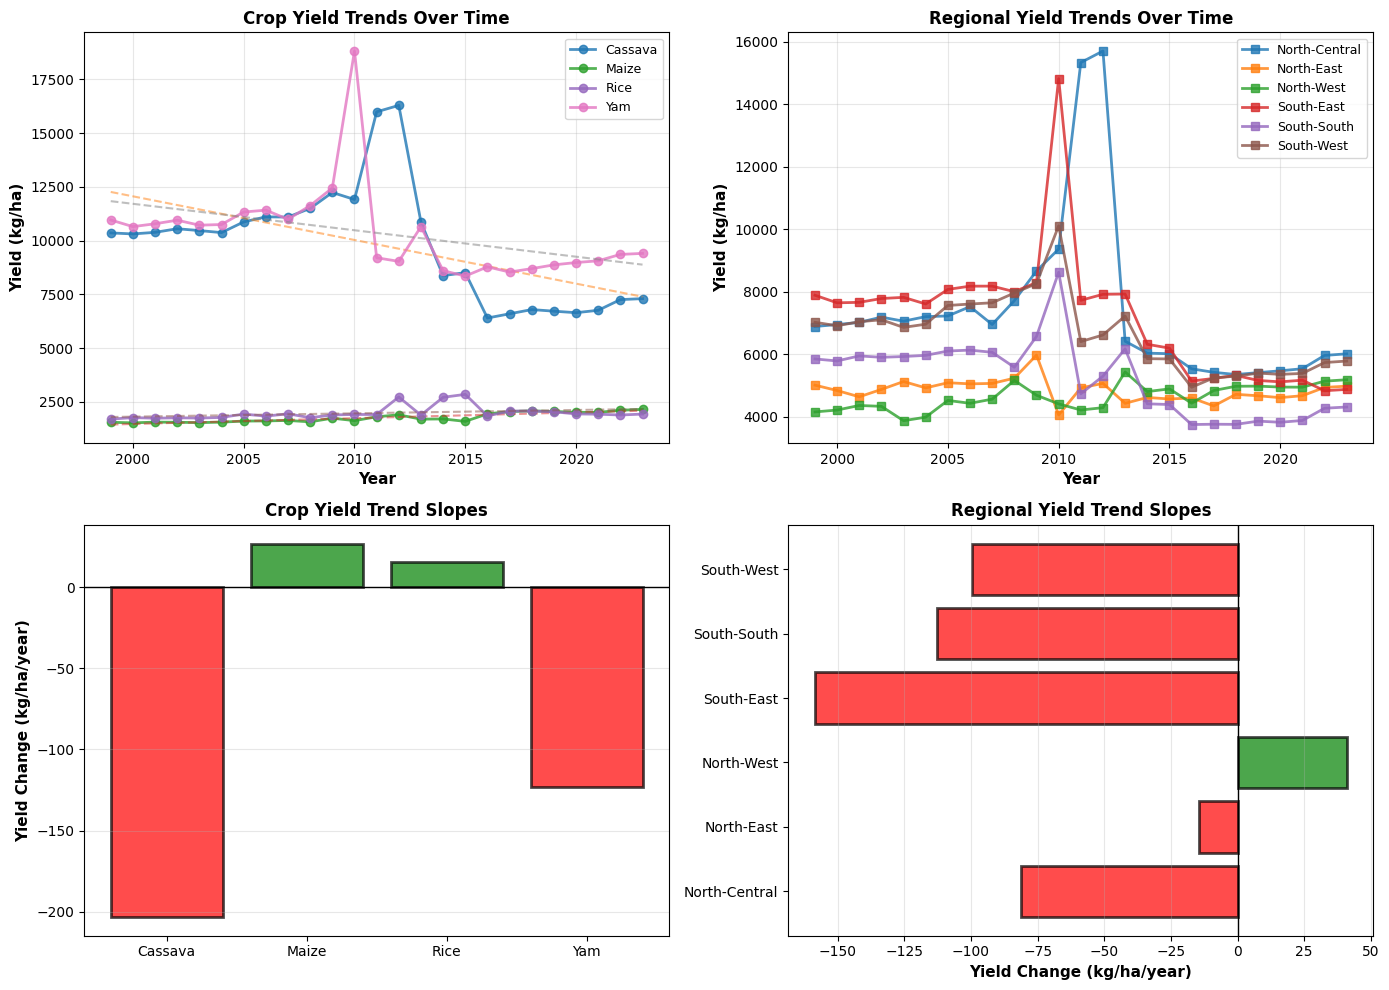

In [32]:
print("\n" + "="*80)
print("TIME-SERIES TREND ANALYSIS: HISTORICAL & PROJECTED YIELDS")
print("="*80)

# Analyze yield trends by crop and region over time
crop_trends = {}
region_trends = {}

for crop in sorted(df['Crop'].unique()):
    crop_mask = df['Crop'] == crop
    yearly_avg = df[crop_mask].groupby('Year')['Yield_kg_per_ha'].agg(['mean', 'std', 'count'])
    crop_trends[crop] = yearly_avg

for region in sorted(df['Region'].unique()):
    region_mask = df['Region'] == region
    yearly_avg = df[region_mask].groupby('Year')['Yield_kg_per_ha'].agg(['mean', 'std', 'count'])
    region_trends[region] = yearly_avg

# Linear trend analysis
print("\n📈 Historical Yield Trends (1999-2023):")
print("\nBy Crop:")
crop_slopes = {}
for crop, trend_data in crop_trends.items():
    years = trend_data.index.values
    yields = trend_data['mean'].values
    z = np.polyfit(years, yields, 1)
    slope = z[0]
    crop_slopes[crop] = slope
    trend_dir = "↑ Increasing" if slope > 0 else "↓ Decreasing"
    print(f"  • {crop}: {slope:+.2f} kg/ha/year {trend_dir}")

print("\nBy Region:")
region_slopes = {}
for region, trend_data in region_trends.items():
    years = trend_data.index.values
    yields = trend_data['mean'].values
    z = np.polyfit(years, yields, 1)
    slope = z[0]
    region_slopes[region] = slope
    trend_dir = "↑ Increasing" if slope > 0 else "↓ Decreasing"
    print(f"  • {region}: {slope:+.2f} kg/ha/year {trend_dir}")

# Time-series visualization with trends
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Crop trends
ax = axes[0, 0]
for crop, trend_data in crop_trends.items():
    years = trend_data.index.values
    yields = trend_data['mean'].values
    ax.plot(years, yields, marker='o', linewidth=2, label=crop, alpha=0.8)
    # Trend line
    z = np.polyfit(years, yields, 1)
    p = np.poly1d(z)
    ax.plot(years, p(years), linestyle='--', linewidth=1.5, alpha=0.5)

ax.set_xlabel('Year', fontsize=11, fontweight='bold')
ax.set_ylabel('Yield (kg/ha)', fontsize=11, fontweight='bold')
ax.set_title('Crop Yield Trends Over Time', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Regional trends
ax = axes[0, 1]
for region, trend_data in region_trends.items():
    years = trend_data.index.values
    yields = trend_data['mean'].values
    ax.plot(years, yields, marker='s', linewidth=2, label=region, alpha=0.8)

ax.set_xlabel('Year', fontsize=11, fontweight='bold')
ax.set_ylabel('Yield (kg/ha)', fontsize=11, fontweight='bold')
ax.set_title('Regional Yield Trends Over Time', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)

# Plot 3: Trend slopes by crop
ax = axes[1, 0]
crops = list(crop_slopes.keys())
slopes = list(crop_slopes.values())
colors = ['red' if s < 0 else 'green' for s in slopes]
bars = ax.bar(crops, slopes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('Yield Change (kg/ha/year)', fontsize=11, fontweight='bold')
ax.set_title('Crop Yield Trend Slopes', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Trend slopes by region
ax = axes[1, 1]
regions = list(region_slopes.keys())
slopes = list(region_slopes.values())
colors = ['red' if s < 0 else 'green' for s in slopes]
bars = ax.barh(regions, slopes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Yield Change (kg/ha/year)', fontsize=11, fontweight='bold')
ax.set_title('Regional Yield Trend Slopes', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../results/Historical_Yield_Trends.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: Historical_Yield_Trends.png")
plt.show()


## 12. Seasonal Climate Pattern Analysis



SEASONAL CLIMATE PATTERN ANALYSIS

🌡️ Average Monthly Climate Conditions:
  Jan: T2M_AVG=24.7°C, Rainfall=64.2mm, Humidity=52.5%
  Feb: T2M_AVG=26.8°C, Rainfall=108.8mm, Humidity=53.5%
  Mar: T2M_AVG=28.4°C, Rainfall=275.9mm, Humidity=58.7%
  Apr: T2M_AVG=28.9°C, Rainfall=584.2mm, Humidity=66.7%
  May: T2M_AVG=28.3°C, Rainfall=844.2mm, Humidity=74.2%
  Jun: T2M_AVG=27.0°C, Rainfall=1216.8mm, Humidity=79.6%
  Jul: T2M_AVG=25.9°C, Rainfall=1389.2mm, Humidity=83.1%
  Aug: T2M_AVG=25.3°C, Rainfall=1447.6mm, Humidity=85.9%
  Sep: T2M_AVG=25.6°C, Rainfall=1457.9mm, Humidity=85.5%
  Oct: T2M_AVG=26.2°C, Rainfall=904.7mm, Humidity=79.4%
  Nov: T2M_AVG=26.0°C, Rainfall=295.0mm, Humidity=66.8%
  Dec: T2M_AVG=24.7°C, Rainfall=68.7mm, Humidity=56.5%

✓ Saved: Seasonal_Climate_Patterns.png


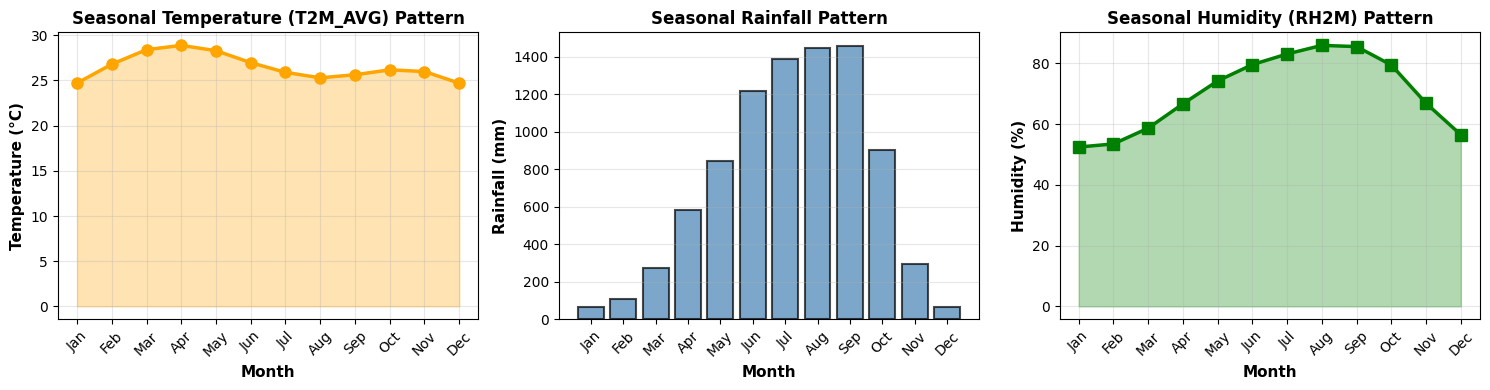

In [33]:
print("\n" + "="*80)
print("SEASONAL CLIMATE PATTERN ANALYSIS")
print("="*80)

# Analyze seasonal patterns - calculate average climate by month
monthly_climate = {}
for month in range(1, 13):
    t2m_avg_col = f'T2M_AVG_m{month}'      # FIXED: Changed from GDD_m{month}
    rainfall_col = f'PRECTOTCORR_m{month}'
    humidity_col = f'RH2M_m{month}'
    
    # Check which columns actually exist and calculate accordingly
    if t2m_avg_col in df.columns:
        t2m_avg = df[t2m_avg_col].mean()
    else:
        # If T2M_AVG doesn't exist, compute from T2M_MAX and T2M_MIN
        max_col = f'T2M_MAX_m{month}'
        min_col = f'T2M_MIN_m{month}'
        if max_col in df.columns and min_col in df.columns:
            t2m_avg = ((df[max_col] + df[min_col]) / 2.0).mean()
        else:
            t2m_avg = np.nan
    
    rainfall = df[rainfall_col].mean() if rainfall_col in df.columns else np.nan
    humidity = df[humidity_col].mean() if humidity_col in df.columns else np.nan
    
    monthly_climate[month] = {
        't2m_avg': t2m_avg,
        'rainfall': rainfall,
        'humidity': humidity
    }

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("\n🌡️ Average Monthly Climate Conditions:")
for month, data in sorted(monthly_climate.items()):
    t2m_str = f"{data['t2m_avg']:.1f}°C" if not np.isnan(data['t2m_avg']) else "N/A"
    rainfall_str = f"{data['rainfall']:.1f}mm" if not np.isnan(data['rainfall']) else "N/A"
    humidity_str = f"{data['humidity']:.1f}%" if not np.isnan(data['humidity']) else "N/A"
    print(f"  {month_names[month-1]:>3}: T2M_AVG={t2m_str}, Rainfall={rainfall_str}, Humidity={humidity_str}")

# Visualize seasonal patterns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

months = sorted(monthly_climate.keys())
t2m_vals = [monthly_climate[m]['t2m_avg'] for m in months]
rainfall_vals = [monthly_climate[m]['rainfall'] for m in months]
humidity_vals = [monthly_climate[m]['humidity'] for m in months]
x_labels = [month_names[m-1] for m in months]

# T2M_AVG seasonal pattern (FIXED: Changed from GDD)
ax = axes[0]
ax.plot(months, t2m_vals, marker='o', linewidth=2.5, color='orange', markersize=8)
ax.fill_between(months, t2m_vals, alpha=0.3, color='orange')
ax.set_xlabel('Month', fontsize=11, fontweight='bold')
ax.set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
ax.set_title('Seasonal Temperature (T2M_AVG) Pattern', fontsize=12, fontweight='bold')  # FIXED: Updated title
ax.set_xticks(months)
ax.set_xticklabels(x_labels, rotation=45)
ax.grid(True, alpha=0.3)

# Rainfall seasonal pattern
ax = axes[1]
ax.bar(months, rainfall_vals, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Month', fontsize=11, fontweight='bold')
ax.set_ylabel('Rainfall (mm)', fontsize=11, fontweight='bold')
ax.set_title('Seasonal Rainfall Pattern', fontsize=12, fontweight='bold')
ax.set_xticks(months)
ax.set_xticklabels(x_labels, rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Humidity seasonal pattern
ax = axes[2]
ax.plot(months, humidity_vals, marker='s', linewidth=2.5, color='green', markersize=8)
ax.fill_between(months, humidity_vals, alpha=0.3, color='green')
ax.set_xlabel('Month', fontsize=11, fontweight='bold')
ax.set_ylabel('Humidity (%)', fontsize=11, fontweight='bold')
ax.set_title('Seasonal Humidity (RH2M) Pattern', fontsize=12, fontweight='bold')
ax.set_xticks(months)
ax.set_xticklabels(x_labels, rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
try:
    plt.savefig('../results/Seasonal_Climate_Patterns.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved: Seasonal_Climate_Patterns.png")
except OSError as e:
    print(f"\n⚠️ Warning: Could not save file - {e}")
plt.show()

## 13. Adaptation Scenario Modeling: Impact of Interventions



ADAPTATION INTERVENTION SCENARIOS

💡 Adaptation Intervention Effectiveness:
(Yield improvement under extreme climate scenario)

  • No Adaptation: +0% yield boost ✗ Limited
  • Basic Irrigation (20% gain): +20% yield boost ~ Moderate
  • Drought-Resistant Varieties (15% gain): +15% yield boost ✗ Limited
  • Combined Irrigation + Tech (40% gain): +40% yield boost ✓ Effective
  • Full Adaptation Package (50% resilience): +50% yield boost ✓ Effective

✓ Saved: Adaptation_Intervention_Effectiveness.png


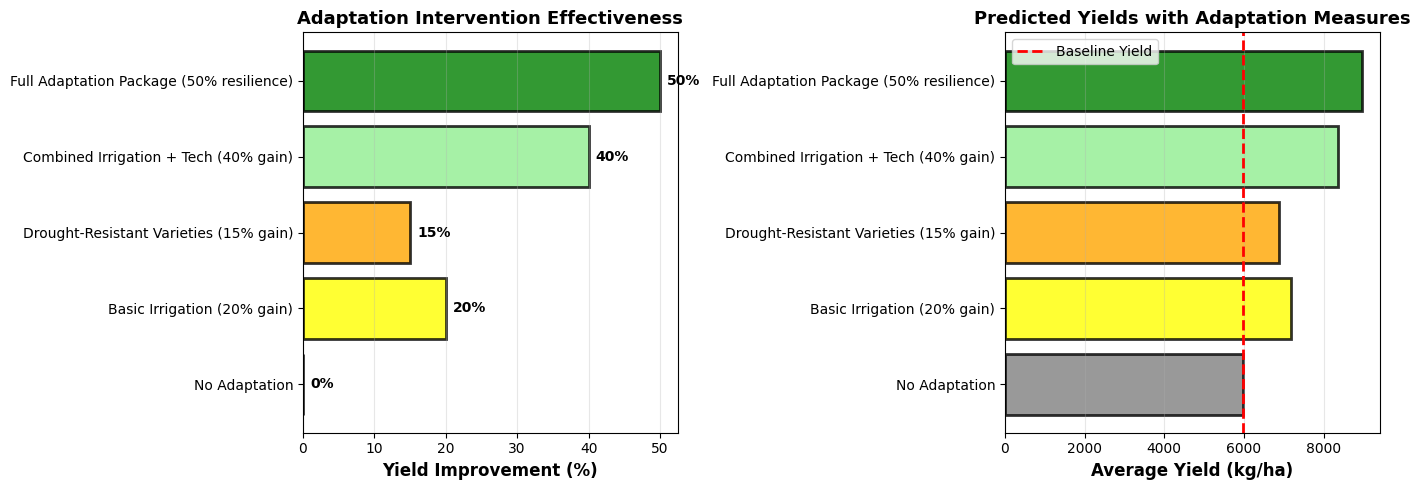

In [34]:
print("\n" + "="*80)
print("ADAPTATION INTERVENTION SCENARIOS")
print("="*80)

# Simulate adaptation interventions under extreme climate scenario
if 'y_scenario' not in locals():
    y_scenario = y_raw.copy()

# Define interventions
interventions = {
    'No Adaptation': 0.00,
    'Basic Irrigation (20% gain)': 0.20,
    'Drought-Resistant Varieties (15% gain)': 0.15,
    'Combined Irrigation + Tech (40% gain)': 0.40,
    'Full Adaptation Package (50% resilience)': 0.50,
}

# Evaluate adaptation effectiveness
print("\n💡 Adaptation Intervention Effectiveness:")
print("(Yield improvement under extreme climate scenario)\n")

adaptation_results = []
for intervention, improvement in interventions.items():
    yield_with_adaptation = y_scenario * (1 + improvement)
    avg_baseline = y_raw.mean()
    avg_adapted = yield_with_adaptation.mean()
    yield_recovery = ((avg_adapted - avg_baseline) / avg_baseline * 100) if avg_baseline > 0 else 0
    
    adaptation_results.append({
        'Intervention': intervention,
        'Yield_Improvement_%': improvement * 100,
        'Avg_Yield': avg_adapted,
        'Yield_Recovery_%': yield_recovery
    })
    
    status = "✓ Effective" if improvement > 0.3 else ("~ Moderate" if improvement > 0.15 else "✗ Limited")
    print(f"  • {intervention}: {improvement*100:+.0f}% yield boost {status}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Yield improvement by intervention
interventions_list = list(interventions.keys())
improvements = [v * 100 for v in interventions.values()]

colors = ['gray', 'yellow', 'orange', 'lightgreen', 'green']
bars = ax1.barh(interventions_list, improvements, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

ax1.set_xlabel('Yield Improvement (%)', fontsize=12, fontweight='bold')
ax1.set_title('Adaptation Intervention Effectiveness', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

for bar, val in zip(bars, improvements):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}%',
            va='center', fontweight='bold', fontsize=10)

# Yield comparison by intervention
baseline_yield = y_raw.mean()
adapted_yields = [baseline_yield * (1 + imp) for imp in interventions.values()]

ax2.barh(interventions_list, adapted_yields, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax2.axvline(x=baseline_yield, color='red', linestyle='--', linewidth=2, label='Baseline Yield')
ax2.set_xlabel('Average Yield (kg/ha)', fontsize=12, fontweight='bold')
ax2.set_title('Predicted Yields with Adaptation Measures', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
try:
    plt.savefig('../results/Adaptation_Intervention_Effectiveness.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved: Adaptation_Intervention_Effectiveness.png")
except OSError as e:
    print(f"\n⚠️ Warning: Could not save file - {e}")
plt.show()


## 14. Climate Resilience Indices by Crop & Region



CLIMATE RESILIENCE INDICES

🛡️ Top 10 Most Resilient Crop-Region Combinations:
  • Maize in South-East: 0.935 (Yield: 1849 kg/ha)
  • Maize in South-West: 0.927 (Yield: 1849 kg/ha)
  • Maize in South-South: 0.924 (Yield: 1593 kg/ha)
  • Yam in North-East: 0.907 (Yield: 10126 kg/ha)
  • Rice in South-East: 0.896 (Yield: 2141 kg/ha)
  • Rice in North-Central: 0.894 (Yield: 2290 kg/ha)
  • Cassava in North-East: 0.890 (Yield: 5889 kg/ha)
  • Cassava in South-West: 0.880 (Yield: 12932 kg/ha)
  • Yam in North-Central: 0.877 (Yield: 13375 kg/ha)
  • Rice in North-East: 0.870 (Yield: 1683 kg/ha)

⚠️ Top 10 Most Vulnerable Crop-Region Combinations:
  • Rice in North-West: 0.850 (Yield: 1802 kg/ha)
  • Maize in North-East: 0.841 (Yield: 1676 kg/ha)
  • Maize in North-West: 0.839 (Yield: 1648 kg/ha)
  • Rice in South-South: 0.837 (Yield: 2007 kg/ha)
  • Cassava in North-West: 0.834 (Yield: 6532 kg/ha)
  • Yam in South-West: 0.807 (Yield: 9876 kg/ha)
  • Yam in South-South: 0.804 (Yield: 8029 kg

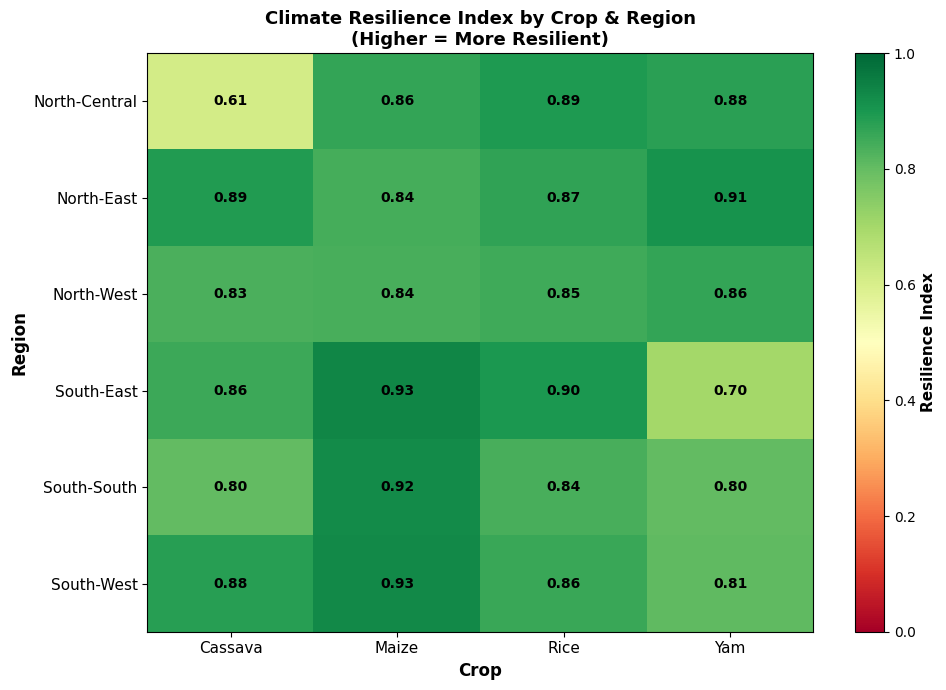

In [35]:
print("\n" + "="*80)
print("CLIMATE RESILIENCE INDICES")
print("="*80)

# Calculate resilience index for each crop-region combination
# Resilience = ability to maintain productivity under climate stress
resilience_data = []

for crop in sorted(df['Crop'].unique()):
    for region in sorted(df['Region'].unique()):
        mask = (df['Crop'] == crop) & (df['Region'] == region)
        
        if mask.sum() > 0:
            baseline = y_raw[mask].mean()
            baseline_std = y_raw[mask].std()
            baseline_cv = baseline_std / baseline if baseline > 0 else 0
            
            # Calculate metrics
            stability_score = 1 / (1 + baseline_cv) if baseline_cv > 0 else 1.0
            adaptive_capacity = 1 - (baseline_cv / 2)  # Systems with lower CV have higher capacity
            adaptive_capacity = np.clip(adaptive_capacity, 0, 1)
            
            # Overall resilience index (0-1 scale)
            resilience_index = (stability_score * 0.5) + (adaptive_capacity * 0.5)
            resilience_index = np.clip(resilience_index, 0, 1)
            
            resilience_data.append({
                'Crop': crop,
                'Region': region,
                'Baseline_Yield': baseline,
                'Stability_Score': stability_score,
                'Resilience_Index': resilience_index,
                'CV': baseline_cv
            })

res_df = pd.DataFrame(resilience_data)
res_df = res_df.sort_values('Resilience_Index', ascending=False)

print("\n🛡️ Top 10 Most Resilient Crop-Region Combinations:")
for idx, row in res_df.head(10).iterrows():
    print(f"  • {row['Crop']} in {row['Region']}: {row['Resilience_Index']:.3f} (Yield: {row['Baseline_Yield']:.0f} kg/ha)")

print("\n⚠️ Top 10 Most Vulnerable Crop-Region Combinations:")
for idx, row in res_df.tail(10).iterrows():
    print(f"  • {row['Crop']} in {row['Region']}: {row['Resilience_Index']:.3f} (Yield: {row['Baseline_Yield']:.0f} kg/ha)")

# Save resilience index
try:
    res_df.to_csv('../results/Resilience_Index_by_CropRegion.csv', index=False)
    print("\n✓ Saved: Resilience_Index_by_CropRegion.csv")
except OSError as e:
    print(f"\n⚠️ Warning: Could not save CSV - {e}")

# Visualization: Resilience heatmap
fig, ax = plt.subplots(figsize=(10, 7))
res_matrix = res_df.pivot_table(index='Region', columns='Crop', values='Resilience_Index')
im = ax.imshow(res_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(res_matrix.columns)))
ax.set_yticks(range(len(res_matrix.index)))
ax.set_xticklabels(res_matrix.columns, fontsize=11)
ax.set_yticklabels(res_matrix.index, fontsize=11)
ax.set_xlabel('Crop', fontsize=12, fontweight='bold')
ax.set_ylabel('Region', fontsize=12, fontweight='bold')
ax.set_title('Climate Resilience Index by Crop & Region\n(Higher = More Resilient)', fontsize=13, fontweight='bold')

for i in range(len(res_matrix.index)):
    for j in range(len(res_matrix.columns)):
        val = res_matrix.iloc[i, j]
        text = ax.text(j, i, f'{val:.2f}', ha="center", va="center",
                      color="white" if val < 0.5 else "black", fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Resilience Index', fontsize=11, fontweight='bold')
plt.tight_layout()
try:
    plt.savefig('../results/Climate_Resilience_Index_Heatmap.png', dpi=300, bbox_inches='tight')
    print('✓ Saved: Climate_Resilience_Index_Heatmap.png')
except OSError as e:
    print(f'⚠️ Warning: Could not save file - {e}')
plt.show() 
